# 🌳 Árbol de Decisión — Regresión de Masa Total de Payload (SpaceX)

Análisis comparativo y sistemático usando `DecisionTreeRegressor` entrenado con **dos conjuntos de features** (Simple, Múltiple) cruzados con **tres particiones distintas** (80/20, 70/30, 60/40) — un total de **6 evaluaciones** que demuestran cómo el modelo responde a la dimensionalidad y al tamaño del conjunto de entrenamiento.

**Variable objetivo (Y):** `total_payload_mass` (kg)

**Conjuntos de variables predictoras (X):**
- **Simple**   →  `thrust_to_weight`
- **Múltiple** →  `thrust_to_weight`, `reused_cores`, `cost_per_launch`

**Dataset sintético** — 1500 lanzamientos generados con la misma semilla y reglas que el notebook de regresión lineal, para que las métricas sean directamente comparables entre ambas familias de modelos.

## I. Configuración Inicial — Importaciones y Estilo Visual

In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

from scripts.database import engine

# Estilo visual consistente con el proyecto
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")

✅ Librerías importadas correctamente
   pandas  3.0.2
   numpy   2.4.4
   seaborn 0.13.2


## II. Generación del Dataset Sintético

Se reproduce **exactamente** el mismo proceso de generación que el notebook de regresión lineal (misma semilla `np.random.seed(42)` y mismas reglas), de modo que las métricas del árbol sean comparables 1-a-1 con las del modelo lineal.

In [2]:
np.random.seed(42)
N = 1500

payload_count    = np.random.choice([1, 2, 3, 4, 5], size=N, p=[0.75, 0.12, 0.07, 0.04, 0.02])
reused_cores     = np.random.choice([0, 1, 2], size=N, p=[0.36, 0.55, 0.09])
core_count       = np.random.choice([1, 2, 3], size=N, p=[0.92, 0.04, 0.04])
thrust_to_weight = np.random.uniform(50, 200, N)
isp_vacuum       = np.random.randint(290, 340, N)
cost_per_launch  = np.random.uniform(6_000_000, 100_000_000, N)
rocket_mass_kg   = np.random.uniform(30_000, 1_420_000, N)

noise = np.random.normal(0, 400, N)  # ruido reducido de 600 a 400

total_payload_mass = (
      1_500  * reused_cores
    +    30  * thrust_to_weight
    +    10  * isp_vacuum
    +   200  * payload_count
    +   150  * (cost_per_launch / 1e7)
    - 4_500                            # intercepto ajustado: de -7000 a -4500
    + noise
)

# Verificación
print(f"min  : {total_payload_mass.min():.0f} kg")
print(f"max  : {total_payload_mass.max():.0f} kg")
print(f"media: {total_payload_mass.mean():.0f} kg")
print(f"negativos: {(total_payload_mass < 0).sum()}")

df = pd.DataFrame({
    'payload_count':      payload_count,
    'reused_cores':       reused_cores,
    'core_count':         core_count,
    'thrust_to_weight':   thrust_to_weight,
    'isp_vacuum':         isp_vacuum,
    'cost_per_launch':    cost_per_launch,
    'rocket_mass_kg':     rocket_mass_kg,
    'total_payload_mass': total_payload_mass,
})

print(f"Observaciones en Y=200 kg: {(df['total_payload_mass'] == 200).sum()}")

min  : 219 kg
max  : 9983 kg
media: 4562 kg
negativos: 0
Observaciones en Y=200 kg: 0


## III. Inspección y Análisis Exploratorio

Antes de modelar, verificamos integridad, distribuciones y relaciones bivariadas. Estos pasos son idénticos al notebook lineal porque los datos son los mismos.

In [3]:
# ── CELDA 3: Inspección ───────────────────────────────────────
print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET SINTÉTICO")
print("=" * 50)
print(df.info())

print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())

  INFORMACIÓN GENERAL DEL DATASET SINTÉTICO
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   payload_count       1500 non-null   int64  
 1   reused_cores        1500 non-null   int64  
 2   core_count          1500 non-null   int64  
 3   thrust_to_weight    1500 non-null   float64
 4   isp_vacuum          1500 non-null   int64  
 5   cost_per_launch     1500 non-null   float64
 6   rocket_mass_kg      1500 non-null   float64
 7   total_payload_mass  1500 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 93.9 KB
None

📊 Valores nulos por columna:
payload_count         0
reused_cores          0
core_count            0
thrust_to_weight      0
isp_vacuum            0
cost_per_launch       0
rocket_mass_kg        0
total_payload_mass    0
dtype: int64


In [4]:
# --Celda 4 ---
df.describe()

,payload_count,reused_cores,core_count,thrust_to_weight,isp_vacuum,cost_per_launch,rocket_mass_kg,total_payload_mass
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1.500000e+03,1.500000e+03,1500.000000
mean,1.477333,0.729333,1.108000,124.889541,314.412667,5.150410e+07,7.157173e+05,4561.849027
std,0.954687,0.606892,0.408796,43.449178,14.243371,2.676056e+07,3.918020e+05,1696.788828
min,1.000000,0.000000,1.000000,50.034056,290.000000,6.022654e+06,3.007343e+04,218.609584
25%,1.000000,0.000000,1.000000,87.271510,302.000000,2.853786e+07,3.867955e+05,3271.821749
50%,1.000000,1.000000,1.000000,123.412570,314.000000,5.134465e+07,7.162126e+05,4535.467965
75%,2.000000,1.000000,1.000000,162.727554,327.000000,7.368344e+07,1.042969e+06,5740.642790
max,5.000000,2.000000,3.000000,199.902545,339.000000,9.989704e+07,1.419312e+06,9982.924081


array([[<Axes: title={'center': 'payload_count'}>,
        <Axes: title={'center': 'reused_cores'}>,
        <Axes: title={'center': 'core_count'}>],
       [<Axes: title={'center': 'thrust_to_weight'}>,
        <Axes: title={'center': 'isp_vacuum'}>,
        <Axes: title={'center': 'cost_per_launch'}>],
       [<Axes: title={'center': 'rocket_mass_kg'}>,
        <Axes: title={'center': 'total_payload_mass'}>, <Axes: >]],
      dtype=object)

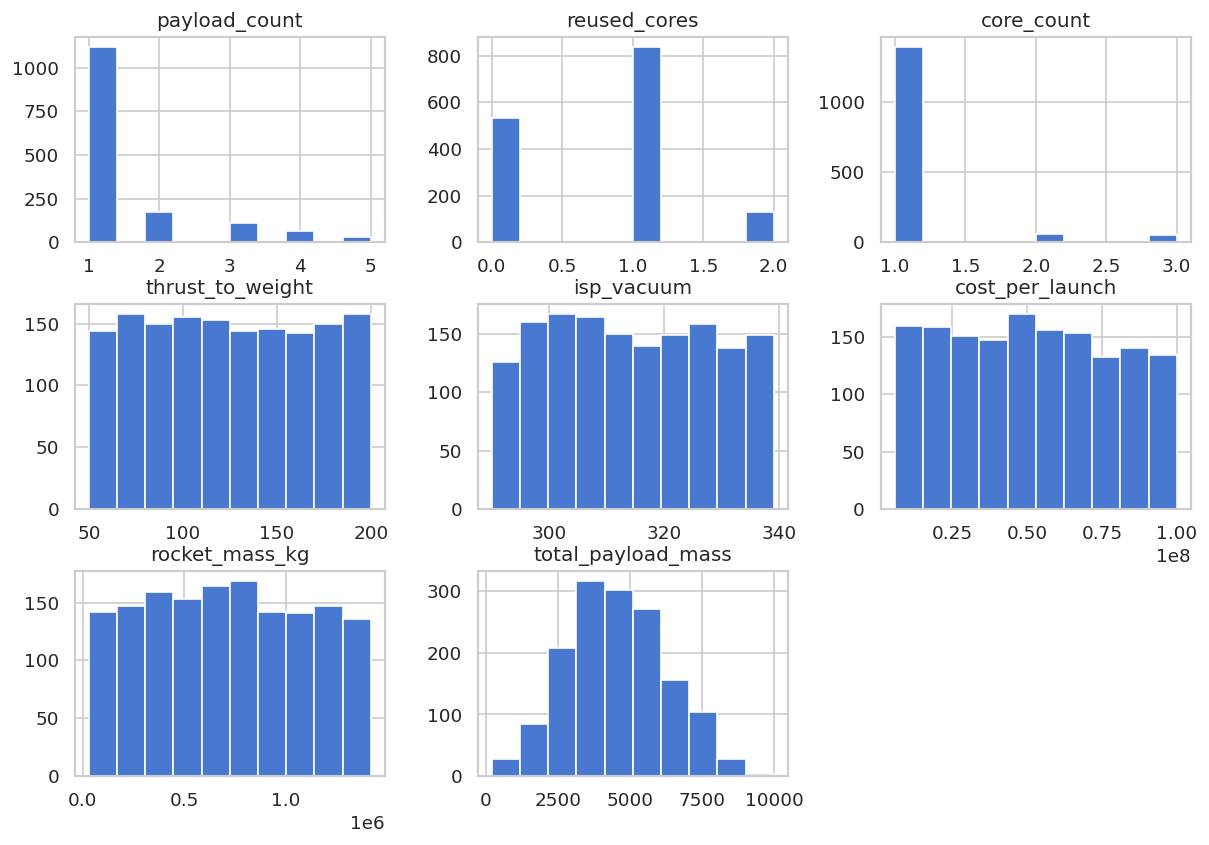

In [5]:
# -- Celda 5 --
df.hist(figsize=(12,8))

<Axes: >

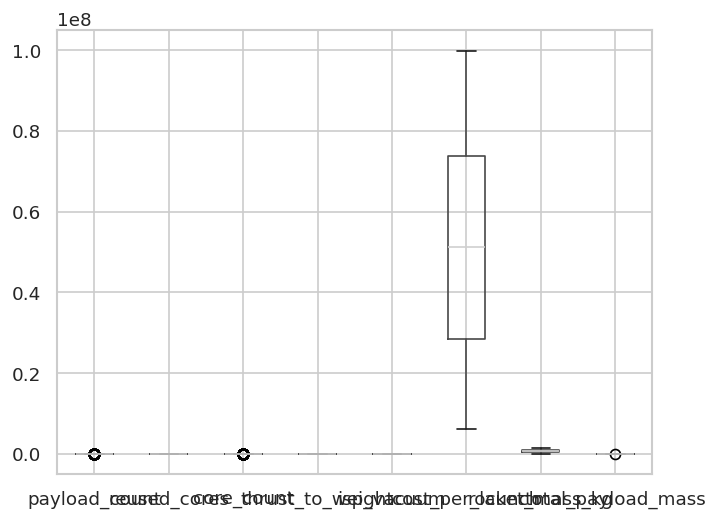

In [6]:
# -- Celda 6 --
df.boxplot()

<Axes: >

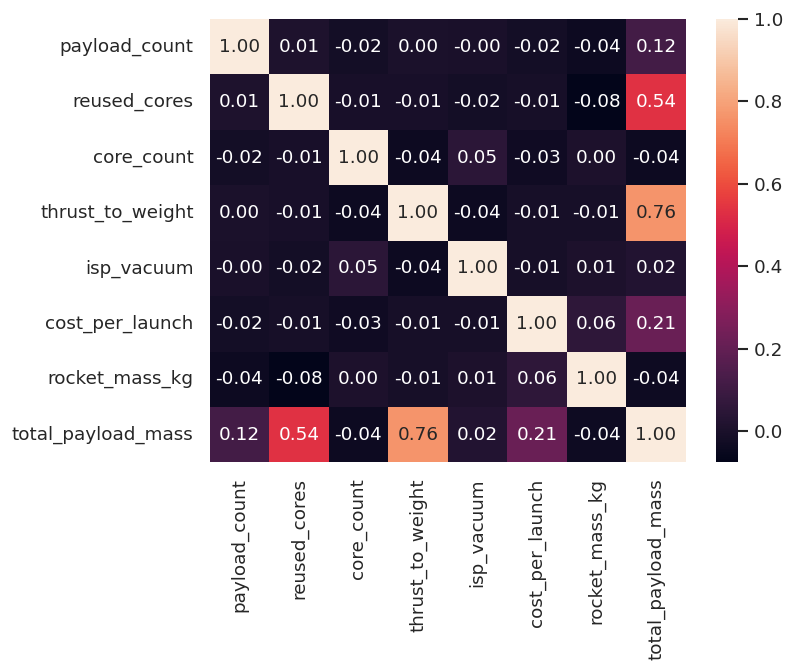

In [7]:
# -- Celda 7 --
df.corr()['total_payload_mass'].sort_values()
# También visual:
sns.heatmap(df.corr(), annot=True, fmt='.2f')

In [8]:
# -- Celda 8 --
df.skew()

payload_count         2.091554
reused_cores          0.215336
core_count            3.881423
thrust_to_weight      0.033379
isp_vacuum            0.036750
cost_per_launch       0.054753
rocket_mass_kg        0.028171
total_payload_mass    0.151230
dtype: float64

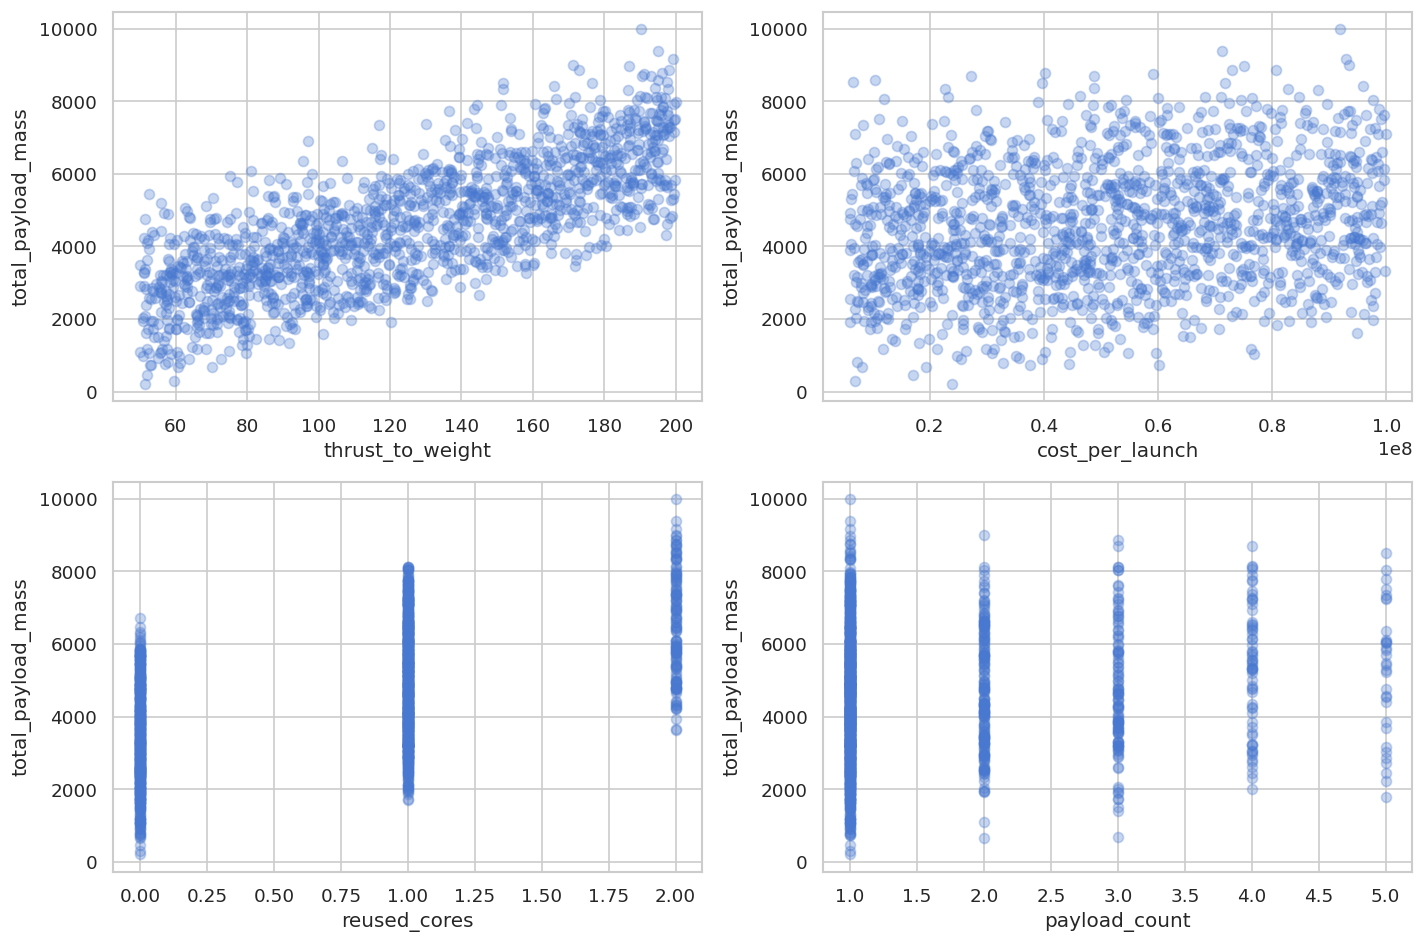

In [9]:
# -- Celda 9 --
features = ['thrust_to_weight','cost_per_launch',
            'reused_cores','payload_count']

fig, axes = plt.subplots(2, 2, figsize=(12,8))
for ax, col in zip(axes.flatten(), features):
    ax.scatter(df[col], df['total_payload_mass'], alpha=0.3)
    ax.set_xlabel(col)
    ax.set_ylabel('total_payload_mass')
plt.tight_layout()

## IV. Bloque de Lógica — Función de Evaluación por Split

Definimos una función reutilizable que entrena, evalúa y visualiza el `DecisionTreeRegressor` para cualquier combinación **(features, split)**. La firma se inspira en el ejemplo guía pero acepta varias columnas predictoras y una etiqueta de modelo (`Simple` / `Múltiple` / `Múltiple`).

**Notas técnicas importantes**

- El árbol de decisión **no requiere escalado** de las variables (parte por umbrales del tipo `x ≤ valor`, no por distancias). Por eso se omite `MinMaxScaler`.
- Se mantiene `random_state=42` en ambas funciones (split y modelo) para reproducibilidad.
- La función guarda dos gráficos por evaluación: **residuos** (con tendencia LOWESS) y **predicción vs. real**.

In [10]:
# ── CELDA 2: Función de evaluación reutilizable ──────────────
import os as _os

_GRAFICAS = _os.path.join(_os.path.dirname(_os.path.abspath('__file__')),
                          '..', 'data', 'graficas')
_os.makedirs(_GRAFICAS, exist_ok=True)


def evaluar_split(df, features, target, test_size, modelo_label, split_label,
                  resultados_globales, save_dir=_GRAFICAS):
    """
    Entrena un DecisionTreeRegressor, calcula métricas y genera
    dos gráficos: residuos y predicciones vs. reales.

    Parámetros
    ----------
    df                  : DataFrame con todas las columnas
    features            : list[str], columnas predictoras
    target              : str, columna objetivo
    test_size           : float, fracción de prueba (p.ej. 0.20)
    modelo_label        : str, etiqueta del modelo ('Simple' / 'Múltiple')
    split_label         : str, etiqueta del split ('80/20', '70/30', '60/40')
    resultados_globales : list, donde se agregan los resultados
    save_dir            : str, directorio donde guardar las gráficas

    Retorna
    -------
    modelo, y_test, y_pred
    """
    X = df[features].values
    y = df[target].values

    train_pct = int((1 - test_size) * 100)
    test_pct  = int(test_size * 100)

    # ── 1. Partición
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    print(f"\n{'='*60}")
    print(f"  {modelo_label}  —  Split {split_label}  ({train_pct}% / {test_pct}%)")
    print(f"{'='*60}")
    print(f"  Features ({len(features)}): {features}")
    print(f"  Train: {X_train.shape[0]:,} muestras  |  "
          f"Test: {X_test.shape[0]:,} muestras")

    # ── 2. Entrenamiento
    modelo = DecisionTreeRegressor(random_state=42)
    modelo.fit(X_train, y_train)

    # ── 3. Predicciones
    y_pred = modelo.predict(X_test)

    # ── 4. Métricas
    r2   = r2_score(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)

    print(f"\n  📊 MÉTRICAS")
    print(f"  {'─'*45}")
    print(f"  R²   (Coef. Determinación) : {r2:.4f}  ({r2*100:.2f}%)")
    print(f"       → El modelo explica el {r2*100:.1f}% de la varianza")
    print(f"         de la masa total de payload.")
    print(f"  MSE  (Error Cuadrático Med): {mse:,.2f}")
    print(f"       → Penaliza errores grandes; sensible a outliers.")
    print(f"  RMSE (Raíz del MSE)        : {rmse:,.2f} kg")
    print(f"       → Error promedio en la misma unidad que Y.")
    print(f"  MAE  (Error Absoluto Med)  : {mae:,.2f} kg")
    print(f"       → Desviación promedio absoluta de las predicciones.")
    print(f"  📐 Estructura del árbol     : "
          f"profundidad={modelo.get_depth()}  |  hojas={modelo.get_n_leaves()}")

    # Guardar para tabla consolidada
    resultados_globales.append({
        'Modelo':   modelo_label,
        'Split':    split_label,
        'Train%':   train_pct,
        'Test%':    test_pct,
        'Features': len(features),
        'R²':       round(r2,   4),
        'MSE':      round(mse,  2),
        'RMSE':     round(rmse, 2),
        'MAE':      round(mae,  2),
        'Prof.':    modelo.get_depth(),
        'Hojas':    modelo.get_n_leaves(),
    })

    # ── 5. Gráfico 1 — Residuos (Errores) ────────────────────
    residuos = y_test - y_pred
    slug     = (f"{modelo_label}_{split_label}"
                .replace('/', '-').replace(' ', '_')
                .replace('(', '').replace(')', '').lower())

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'DecisionTreeRegressor — {modelo_label}  ·  Split {split_label}',
                 fontsize=14, fontweight='bold')

    # Scatter residuos con línea ideal en 0 y LOWESS
    axes[0].scatter(y_pred, residuos, alpha=0.35, s=14, color='#4ecdc4',
                    label='Residuos')
    axes[0].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2,
                    label='Línea ideal (error = 0)')
    # Tendencia LOWESS para detectar patrones sistemáticos
    orden_idx  = np.argsort(y_pred)
    lowess_res = sm.nonparametric.lowess(
        residuos[orden_idx], y_pred[orden_idx], frac=0.4
    )
    axes[0].plot(lowess_res[:, 0], lowess_res[:, 1],
                 color='#ffa07a', linewidth=2.5, label='Tendencia LOWESS')
    axes[0].set_title('Gráfico de Errores (Residuos)', fontweight='bold')
    axes[0].set_xlabel('Valores Predichos (kg)')
    axes[0].set_ylabel('Residuos (kg)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # ── Gráfico 2 — Predicción vs. Real ──────────────────────
    minval = min(y_test.min(), y_pred.min())
    maxval = max(y_test.max(), y_pred.max())
    axes[1].scatter(y_test, y_pred, alpha=0.30, s=14, color='#95e1d3',
                    label='Predicciones')
    axes[1].plot([minval, maxval], [minval, maxval],
                 color='#ff6b6b', linewidth=2, linestyle='--',
                 label='Predicción perfecta')
    axes[1].set_title('Predicción vs. Valor Real', fontweight='bold')
    axes[1].set_xlabel('Valor Real (kg)')
    axes[1].set_ylabel('Valor Predicho (kg)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = _os.path.join(save_dir, f'dt_{slug}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  💾 Gráfico guardado → {fname}")

    return modelo, y_test, y_pred


# Contenedor de resultados para el análisis consolidado
resultados_globales = []

# Definición de los tres conjuntos de features (idéntica a la regresión lineal)
features_simple   = ['thrust_to_weight']
features_multiple = ['thrust_to_weight', 'reused_cores', 'cost_per_launch']
target            = 'total_payload_mass'

print("✅ Función evaluar_split definida correctamente.")
print(f"   Directorio de gráficas: {_GRAFICAS}")
print(f"\n📐 Conjuntos de features:")
print(f"   Simple   ({len(features_simple)}): {features_simple}")
print(f"   Múltiple ({len(features_multiple)}): {features_multiple}")

✅ Función evaluar_split definida correctamente.
   Directorio de gráficas: /home/elkin_contreras/repositorio/Grupo1_Contreras_Ortiz/05-jupyter-impl/notebooks/../data/graficas

📐 Conjuntos de features:
   Simple   (1): ['thrust_to_weight']
   Múltiple (3): ['thrust_to_weight', 'reused_cores', 'cost_per_launch']


---
## V. Modelo SIMPLE — `thrust_to_weight` como única predictora

Análogo a la regresión lineal simple del notebook anterior. El árbol intentará segmentar el rango de `thrust_to_weight` en intervalos y asignar a cada intervalo una masa predicha. Probamos los tres splits para evaluar la estabilidad.


  Simple  —  Split 80/20  (80% / 20%)
  Features (1): ['thrust_to_weight']
  Train: 1,200 muestras  |  Test: 300 muestras

  📊 MÉTRICAS
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.1725  (17.25%)
       → El modelo explica el 17.2% de la varianza
         de la masa total de payload.
  MSE  (Error Cuadrático Med): 2,339,210.37
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 1,529.45 kg
       → Error promedio en la misma unidad que Y.
  MAE  (Error Absoluto Med)  : 1,249.53 kg
       → Desviación promedio absoluta de las predicciones.
  📐 Estructura del árbol     : profundidad=44  |  hojas=1200


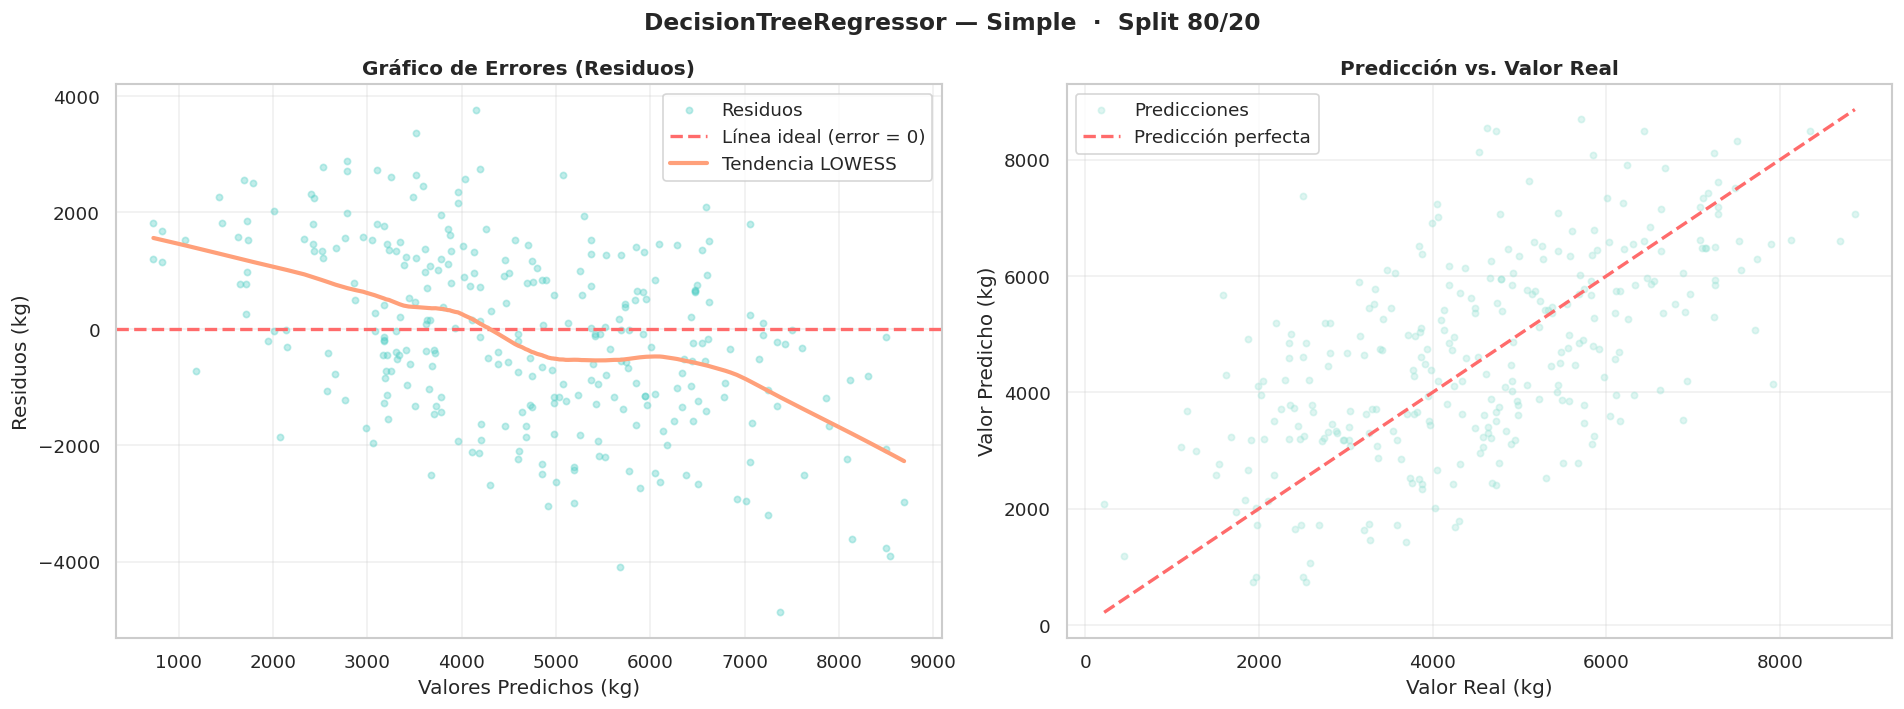

  💾 Gráfico guardado → /home/elkin_contreras/repositorio/Grupo1_Contreras_Ortiz/05-jupyter-impl/notebooks/../data/graficas/dt_simple_80-20.png


In [11]:
# ── CELDA 3: Modelo Simple — Split 80/20 ─────────────────────
modelo_s1_80, y_te_s1_80, y_pr_s1_80 = evaluar_split(
    df, features_simple, target,
    test_size=0.20,
    modelo_label='Simple',
    split_label='80/20',
    resultados_globales=resultados_globales,
)


  Simple  —  Split 70/30  (70% / 30%)
  Features (1): ['thrust_to_weight']
  Train: 1,050 muestras  |  Test: 450 muestras

  📊 MÉTRICAS
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.1475  (14.75%)
       → El modelo explica el 14.8% de la varianza
         de la masa total de payload.
  MSE  (Error Cuadrático Med): 2,396,673.25
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 1,548.12 kg
       → Error promedio en la misma unidad que Y.
  MAE  (Error Absoluto Med)  : 1,264.29 kg
       → Desviación promedio absoluta de las predicciones.
  📐 Estructura del árbol     : profundidad=37  |  hojas=1050


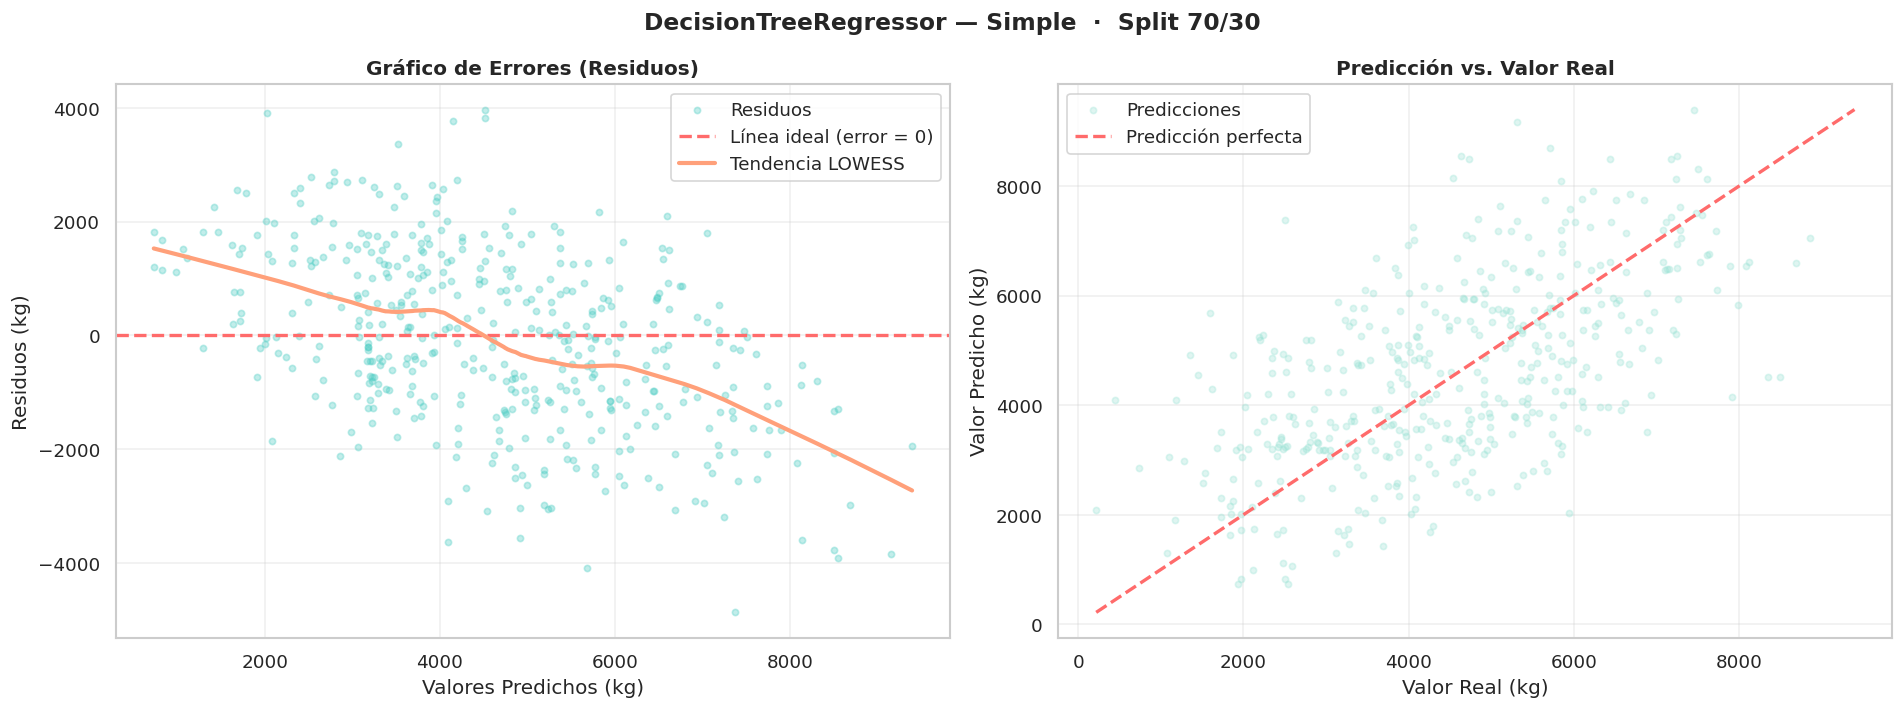

  💾 Gráfico guardado → /home/elkin_contreras/repositorio/Grupo1_Contreras_Ortiz/05-jupyter-impl/notebooks/../data/graficas/dt_simple_70-30.png


In [12]:
# ── CELDA 4: Modelo Simple — Split 70/30 ─────────────────────
modelo_s1_70, y_te_s1_70, y_pr_s1_70 = evaluar_split(
    df, features_simple, target,
    test_size=0.30,
    modelo_label='Simple',
    split_label='70/30',
    resultados_globales=resultados_globales,
)


  Simple  —  Split 60/40  (60% / 40%)
  Features (1): ['thrust_to_weight']
  Train: 900 muestras  |  Test: 600 muestras

  📊 MÉTRICAS
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.1865  (18.65%)
       → El modelo explica el 18.7% de la varianza
         de la masa total de payload.
  MSE  (Error Cuadrático Med): 2,256,628.71
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 1,502.21 kg
       → Error promedio en la misma unidad que Y.
  MAE  (Error Absoluto Med)  : 1,217.63 kg
       → Desviación promedio absoluta de las predicciones.
  📐 Estructura del árbol     : profundidad=29  |  hojas=900


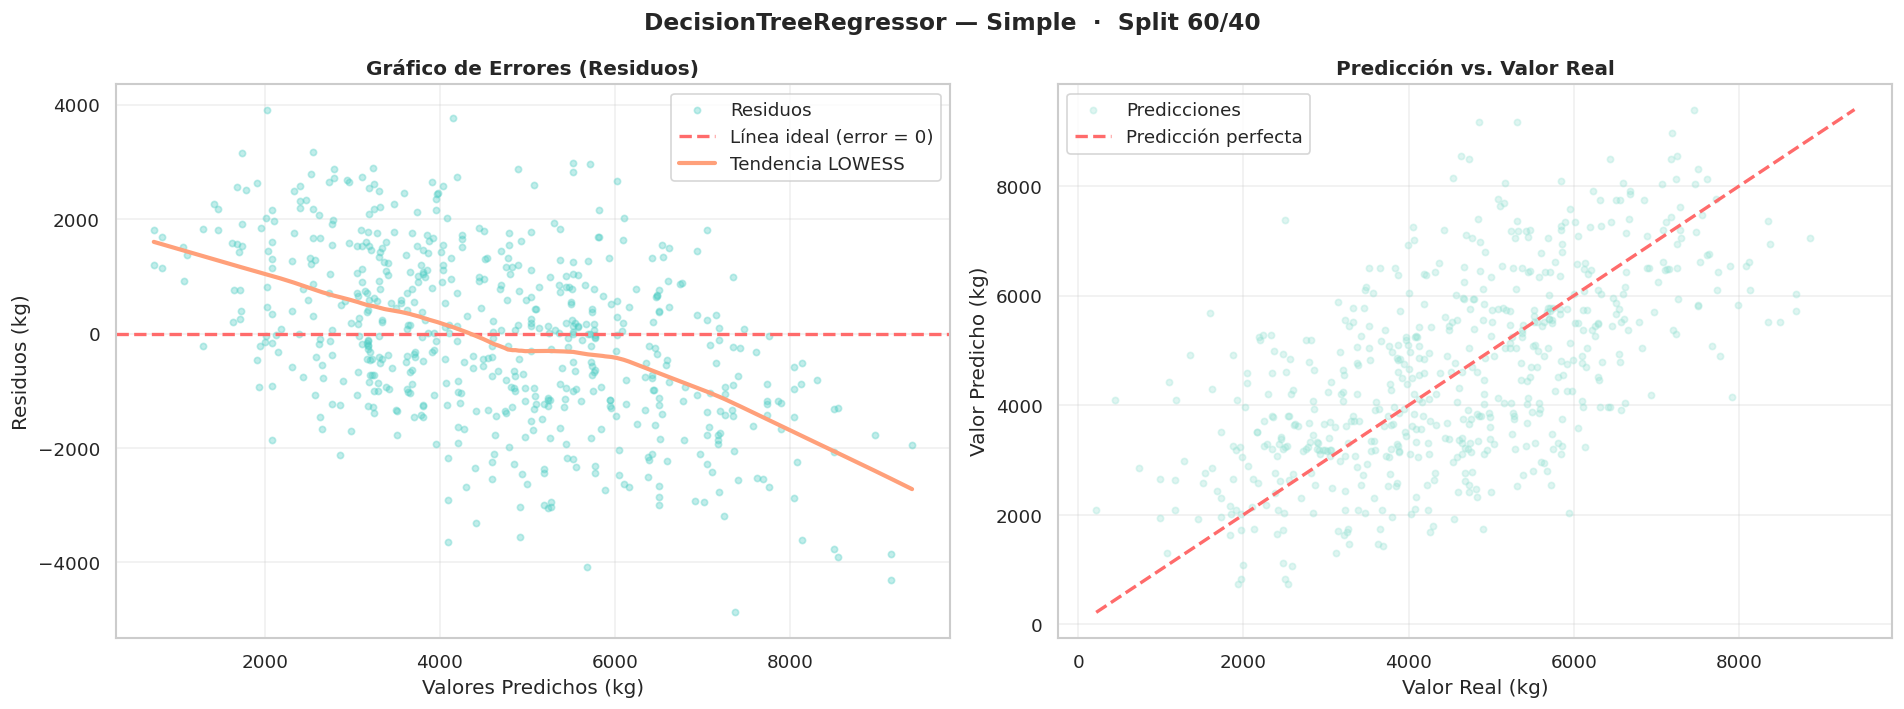

  💾 Gráfico guardado → /home/elkin_contreras/repositorio/Grupo1_Contreras_Ortiz/05-jupyter-impl/notebooks/../data/graficas/dt_simple_60-40.png


In [13]:
# ── CELDA 5: Modelo Simple — Split 60/40 ─────────────────────
modelo_s1_60, y_te_s1_60, y_pr_s1_60 = evaluar_split(
    df, features_simple, target,
    test_size=0.40,
    modelo_label='Simple',
    split_label='60/40',
    resultados_globales=resultados_globales,
)

---
## VII. Modelo MÚLTIPLE — `thrust_to_weight` + `reused_cores` + `cost_per_launch`

Incorporamos `cost_per_launch`, la variable continua de mayor rango. El árbol dispondrá de más cortes posibles y debería alcanzar su mejor R². Pero ojo: más profundidad también significa mayor riesgo de **overfitting**, algo que detectaremos comparando los splits.


  Múltiple  —  Split 80/20  (80% / 20%)
  Features (3): ['thrust_to_weight', 'reused_cores', 'cost_per_launch']
  Train: 1,200 muestras  |  Test: 300 muestras

  📊 MÉTRICAS
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.8289  (82.89%)
       → El modelo explica el 82.9% de la varianza
         de la masa total de payload.
  MSE  (Error Cuadrático Med): 483,717.88
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 695.50 kg
       → Error promedio en la misma unidad que Y.
  MAE  (Error Absoluto Med)  : 553.42 kg
       → Desviación promedio absoluta de las predicciones.
  📐 Estructura del árbol     : profundidad=21  |  hojas=1200


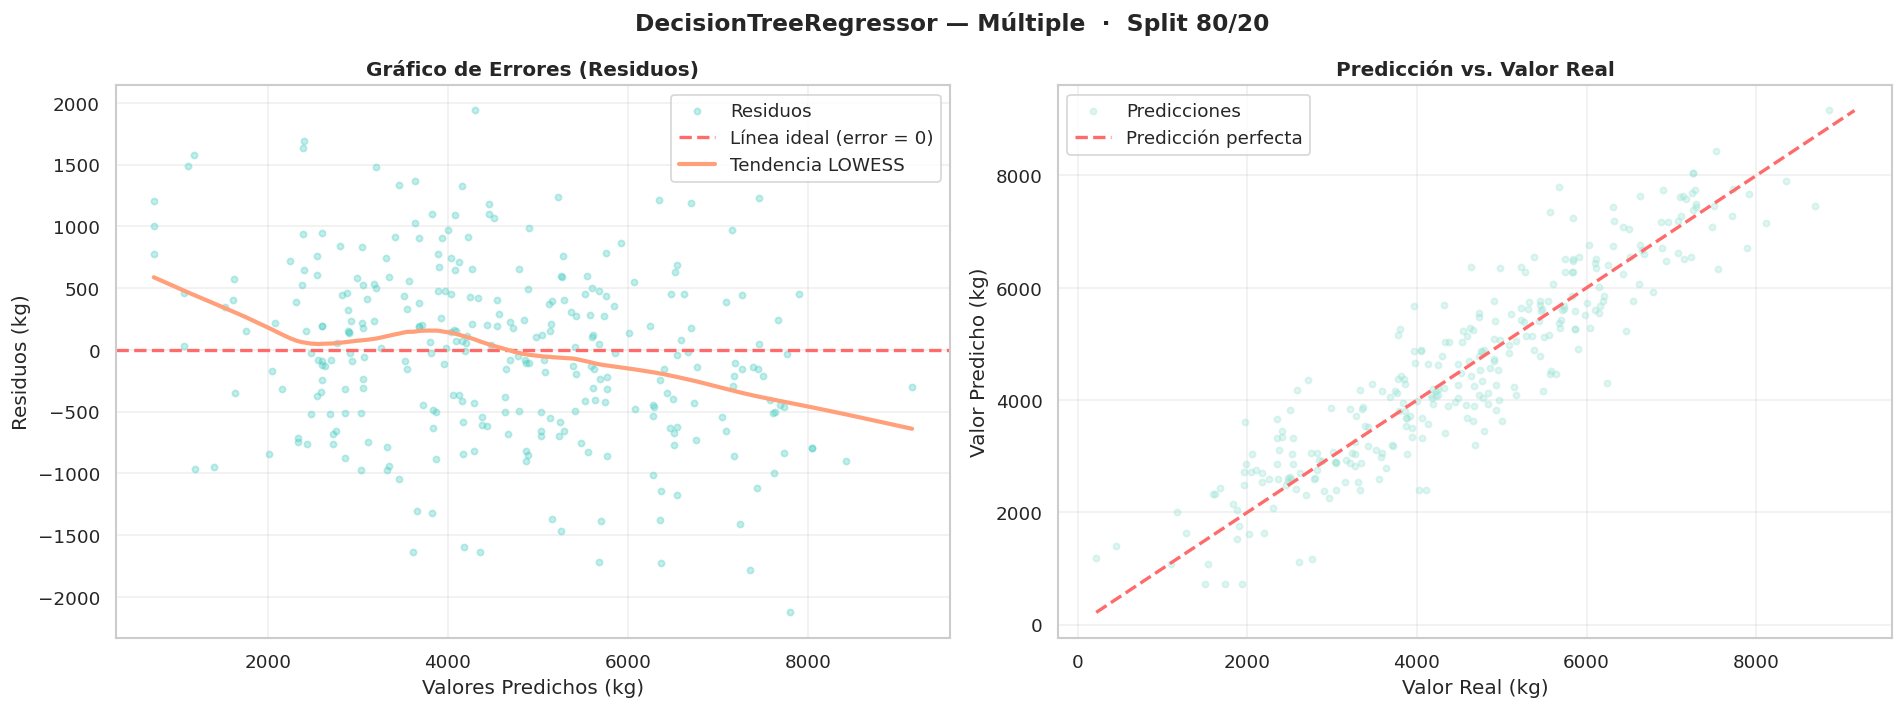

  💾 Gráfico guardado → /home/elkin_contreras/repositorio/Grupo1_Contreras_Ortiz/05-jupyter-impl/notebooks/../data/graficas/dt_múltiple_80-20.png


In [14]:
# ── CELDA 9: Modelo Múltiple — Split 80/20 ───────────────────
modelo_m_80, y_te_m_80, y_pr_m_80 = evaluar_split(
    df, features_multiple, target,
    test_size=0.20,
    modelo_label='Múltiple',
    split_label='80/20',
    resultados_globales=resultados_globales,
)


  Múltiple  —  Split 70/30  (70% / 30%)
  Features (3): ['thrust_to_weight', 'reused_cores', 'cost_per_launch']
  Train: 1,050 muestras  |  Test: 450 muestras

  📊 MÉTRICAS
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.8248  (82.48%)
       → El modelo explica el 82.5% de la varianza
         de la masa total de payload.
  MSE  (Error Cuadrático Med): 492,591.16
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 701.85 kg
       → Error promedio en la misma unidad que Y.
  MAE  (Error Absoluto Med)  : 559.95 kg
       → Desviación promedio absoluta de las predicciones.
  📐 Estructura del árbol     : profundidad=21  |  hojas=1050


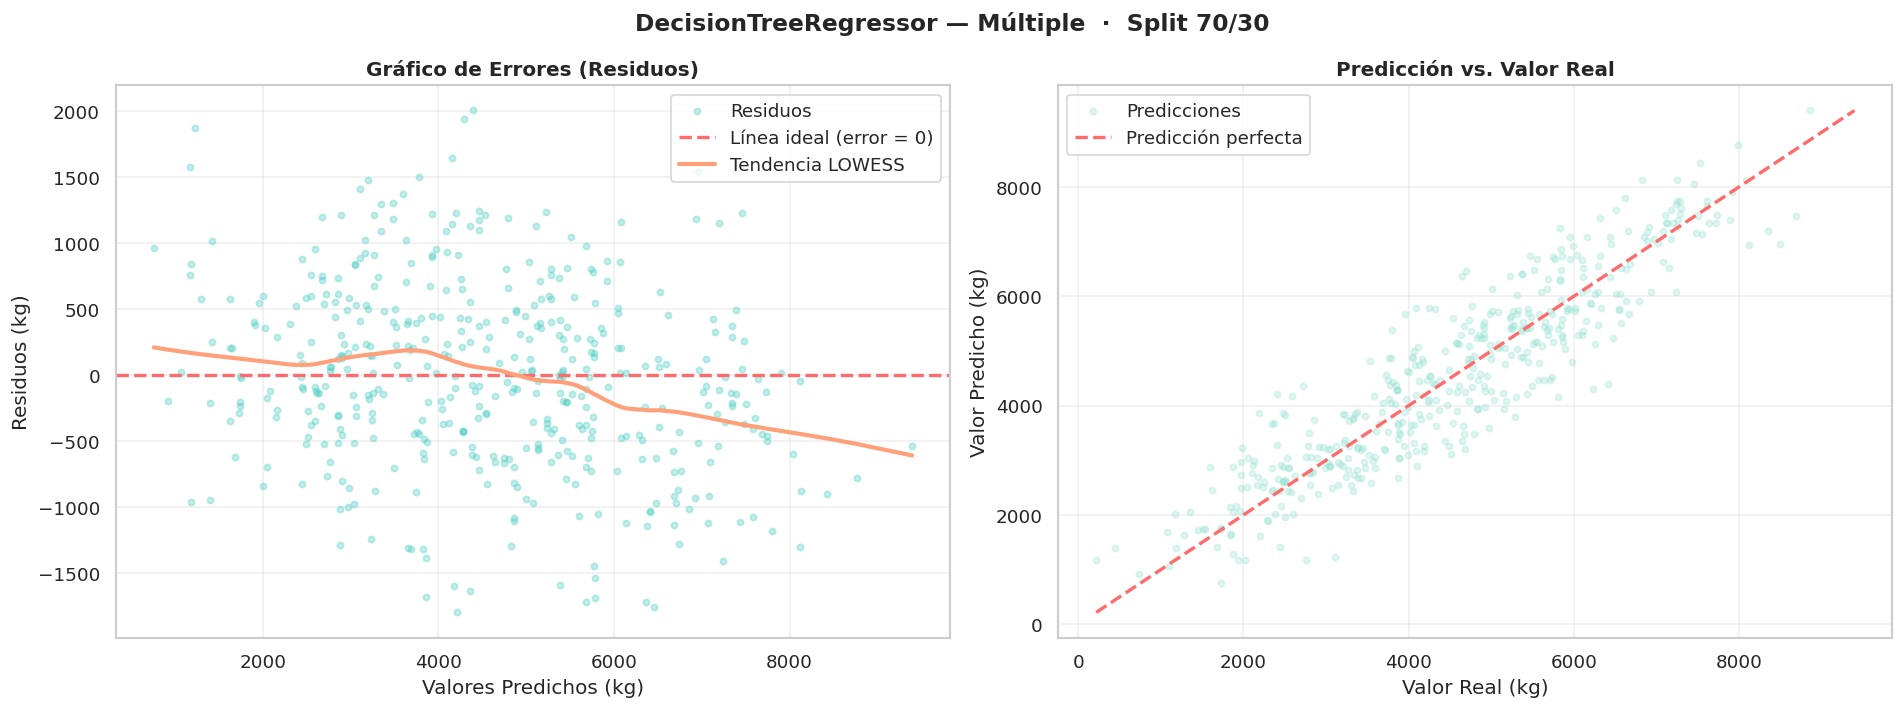

  💾 Gráfico guardado → /home/elkin_contreras/repositorio/Grupo1_Contreras_Ortiz/05-jupyter-impl/notebooks/../data/graficas/dt_múltiple_70-30.png


In [15]:
# ── CELDA 10: Modelo Múltiple — Split 70/30 ──────────────────
modelo_m_70, y_te_m_70, y_pr_m_70 = evaluar_split(
    df, features_multiple, target,
    test_size=0.30,
    modelo_label='Múltiple',
    split_label='70/30',
    resultados_globales=resultados_globales,
)


  Múltiple  —  Split 60/40  (60% / 40%)
  Features (3): ['thrust_to_weight', 'reused_cores', 'cost_per_launch']
  Train: 900 muestras  |  Test: 600 muestras

  📊 MÉTRICAS
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.8355  (83.55%)
       → El modelo explica el 83.6% de la varianza
         de la masa total de payload.
  MSE  (Error Cuadrático Med): 456,202.90
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 675.43 kg
       → Error promedio en la misma unidad que Y.
  MAE  (Error Absoluto Med)  : 539.20 kg
       → Desviación promedio absoluta de las predicciones.
  📐 Estructura del árbol     : profundidad=20  |  hojas=900


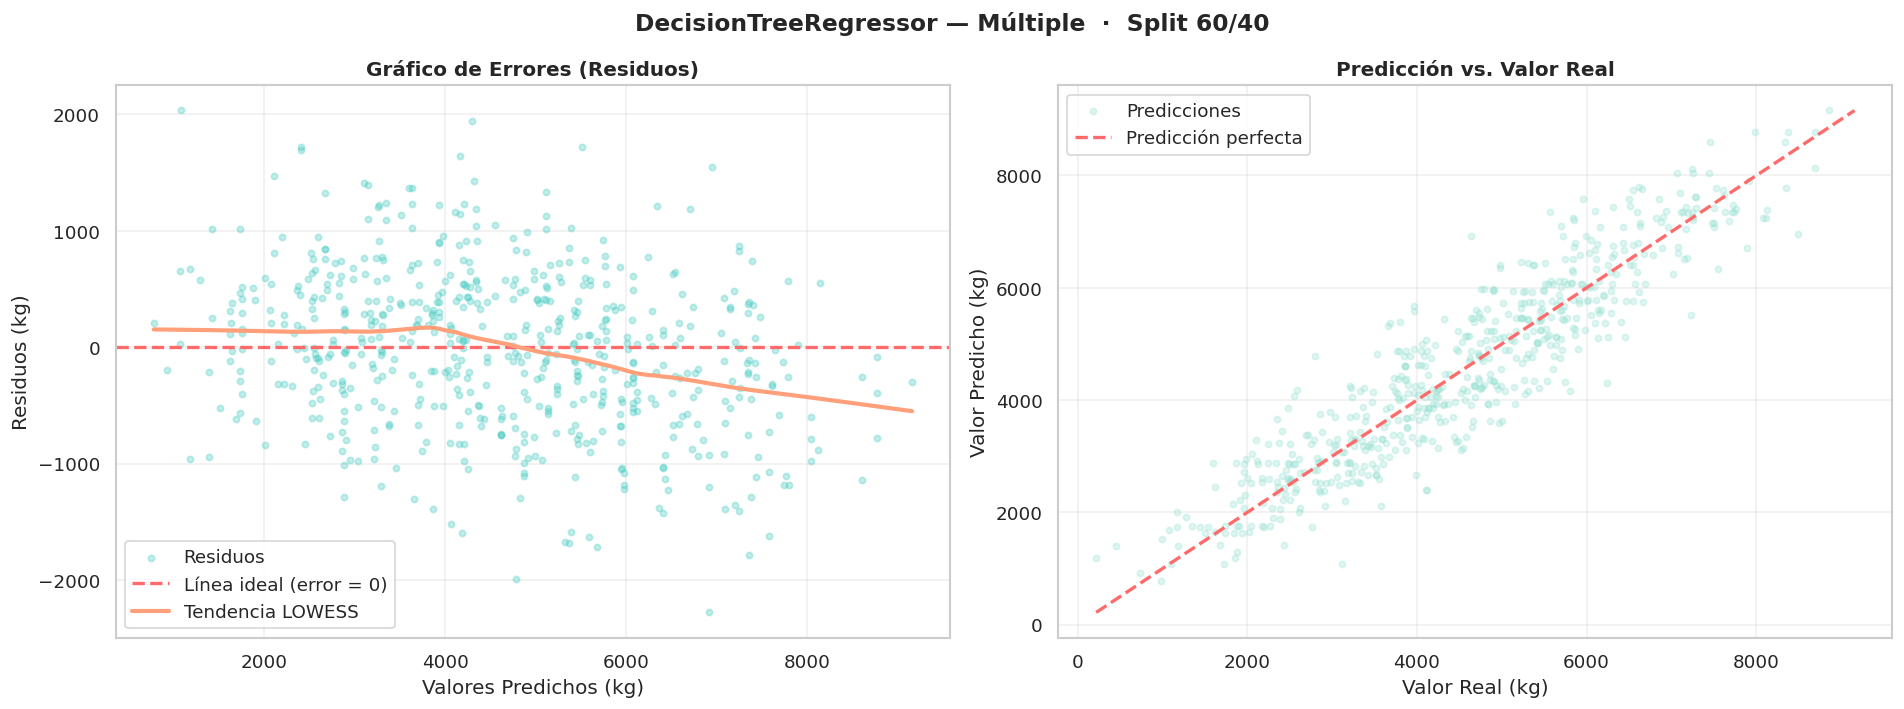

  💾 Gráfico guardado → /home/elkin_contreras/repositorio/Grupo1_Contreras_Ortiz/05-jupyter-impl/notebooks/../data/graficas/dt_múltiple_60-40.png


In [16]:
# ── CELDA 11: Modelo Múltiple — Split 60/40 ──────────────────
modelo_m_60, y_te_m_60, y_pr_m_60 = evaluar_split(
    df, features_multiple, target,
    test_size=0.40,
    modelo_label='Múltiple',
    split_label='60/40',
    resultados_globales=resultados_globales,
)

---
## VIII. Análisis Consolidado (Summary)

Comparamos el rendimiento de las **6 evaluaciones** en una matriz 2×3 (modelos × splits), analizamos las implicaciones de los residuos y emitimos una recomendación sobre si refinar el árbol o escalar a métodos de ensemble.

In [17]:
# ── CELDA 12: Tabla comparativa de las 6 evaluaciones ────────
df_resumen = pd.DataFrame(resultados_globales)

print("=" * 90)
print("        TABLA COMPARATIVA — 2 MODELOS × 3 SPLITS  (6 evaluaciones)")
print("=" * 90)
print(df_resumen.to_string(index=False))
print("=" * 90)

# Pivot: R² por (Modelo × Split) para lectura rápida
print("\n📊 Matriz de R² (filas: modelo, columnas: split):")
pivot_r2 = df_resumen.pivot(index='Modelo', columns='Split', values='R²')
pivot_r2 = pivot_r2.reindex(index=['Simple', 'Múltiple'], columns=['80/20', '70/30', '60/40'])
print(pivot_r2.to_string())

print("\n📊 Matriz de RMSE (kg):")
pivot_rmse = df_resumen.pivot(index='Modelo', columns='Split', values='RMSE')
pivot_rmse = pivot_rmse.reindex(index=['Simple', 'Múltiple'], columns=['80/20', '70/30', '60/40'])
print(pivot_rmse.to_string())

        TABLA COMPARATIVA — 2 MODELOS × 3 SPLITS  (6 evaluaciones)
  Modelo Split  Train%  Test%  Features     R²        MSE    RMSE     MAE  Prof.  Hojas
  Simple 80/20      80     20         1 0.1725 2339210.37 1529.45 1249.53     44   1200
  Simple 70/30      70     30         1 0.1475 2396673.25 1548.12 1264.29     37   1050
  Simple 60/40      60     40         1 0.1865 2256628.71 1502.21 1217.63     29    900
Múltiple 80/20      80     20         3 0.8289  483717.88  695.50  553.42     21   1200
Múltiple 70/30      70     30         3 0.8248  492591.16  701.85  559.95     21   1050
Múltiple 60/40      60     40         3 0.8355  456202.90  675.43  539.20     20    900

📊 Matriz de R² (filas: modelo, columnas: split):
Split      80/20   70/30   60/40
Modelo                          
Simple    0.1725  0.1475  0.1865
Múltiple  0.8289  0.8248  0.8355

📊 Matriz de RMSE (kg):
Split       80/20    70/30    60/40
Modelo                             
Simple    1529.45  1548.12  1502.21
Múl

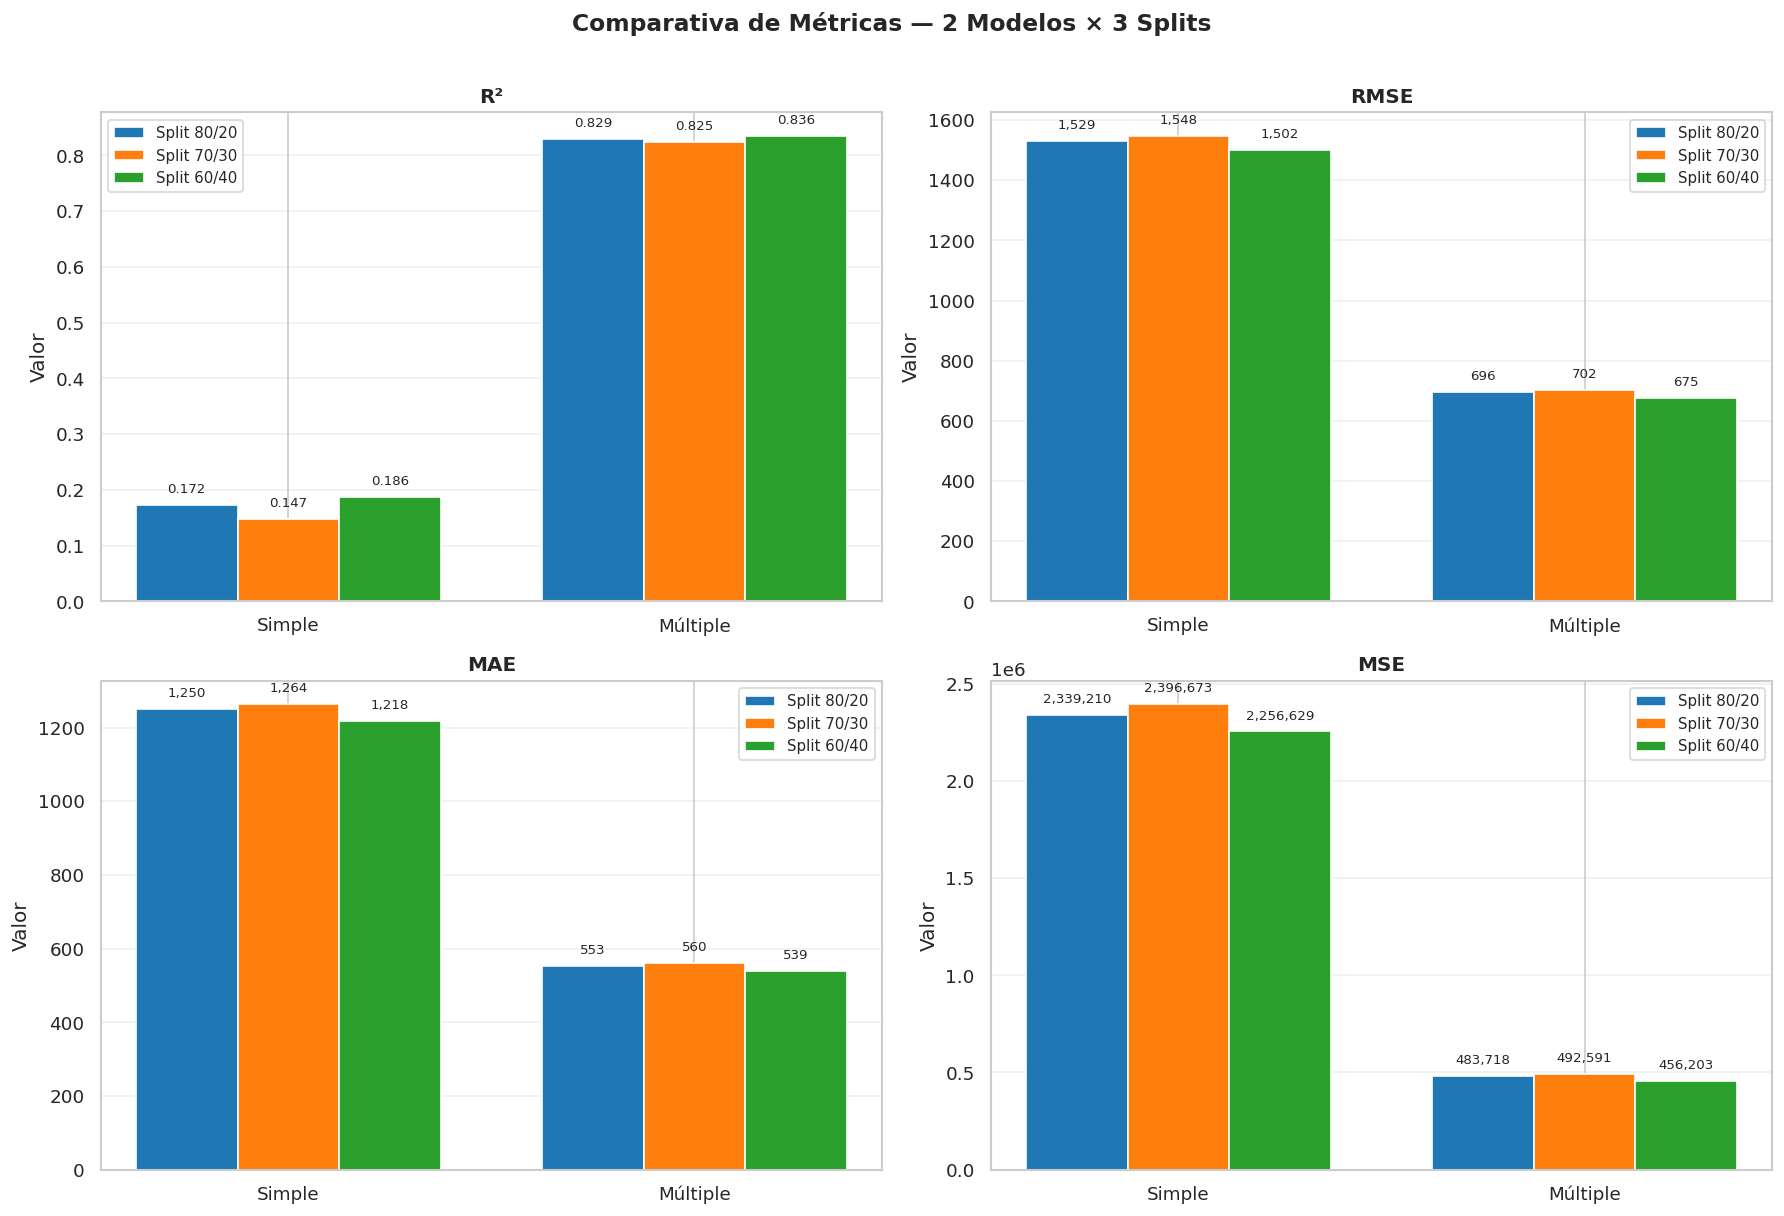

💾 Gráfico comparativo guardado → ../data/graficas/dt_comparativa_6_evaluaciones.png


In [18]:
# ── CELDA 13: Gráfico comparativo de métricas ────────────────
metricas = ['R²', 'RMSE', 'MAE', 'MSE']
colores  = ['#ff6b6b', '#4ecdc4', '#95e1d3', '#ffa07a']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Comparativa de Métricas — 2 Modelos × 3 Splits',
             fontsize=14, fontweight='bold', y=1.01)

# Orden fijo de modelos y splits para la leyenda
orden_modelos = ['Simple', 'Múltiple']
orden_splits  = ['80/20', '70/30', '60/40']
colores_split = {'80/20': '#1f77b4', '70/30': '#ff7f0e', '60/40': '#2ca02c'}

for ax, metrica in zip(axes.flat, metricas):
    pivot = df_resumen.pivot(index='Modelo', columns='Split', values=metrica)
    pivot = pivot.reindex(orden_modelos)[orden_splits]

    x   = np.arange(len(orden_modelos))
    w   = 0.25
    for i, split in enumerate(orden_splits):
        valores = pivot[split].values
        offset  = (i - 1) * w
        barras  = ax.bar(x + offset, valores, w,
                         label=f'Split {split}',
                         color=colores_split[split],
                         edgecolor='white')
        for bar, val in zip(barras, valores):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(valores) * 0.02,
                    f'{val:.3f}' if metrica == 'R²' else f'{val:,.0f}',
                    ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(orden_modelos)
    ax.set_title(metrica, fontweight='bold')
    ax.set_ylabel('Valor')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/graficas/dt_comparativa_6_evaluaciones.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("💾 Gráfico comparativo guardado → ../data/graficas/dt_comparativa_6_evaluaciones.png")

In [19]:
# ── CELDA 14: Análisis interpretativo y recomendación ────────
r2_vals   = df_resumen['R²'].values
rmse_vals = df_resumen['RMSE'].values
mae_vals  = df_resumen['MAE'].values

r2_rango   = r2_vals.max()   - r2_vals.min()
rmse_rango = rmse_vals.max() - rmse_vals.min()

print("=" * 70)
print("   ANÁLISIS CONSOLIDADO — DecisionTreeRegressor (SpaceX)")
print("=" * 70)

print("""
1. VARIACIÓN DEL RENDIMIENTO ENTRE EVALUACIONES
────────────────────────────────────────────────""")
print(f"   R²   máx={r2_vals.max():.4f}  mín={r2_vals.min():.4f}  "
      f"rango={r2_rango:.4f}")
print(f"   RMSE máx={rmse_vals.max():,.2f} kg  mín={rmse_vals.min():,.2f} kg  "
      f"rango={rmse_rango:,.2f} kg")

if r2_rango < 0.05:
    print("""
   ✅ El R² es estable en las 6 evaluaciones (variación < 0.05).
      El modelo generaliza bien y no depende críticamente del
      tamaño de la partición ni del conjunto de features elegido.""")
else:
    print("""
   ⚠️  El R² varía notablemente entre evaluaciones (variación ≥ 0.05).
      Esto suele indicar dos cosas a la vez:
        (a) añadir features mejora claramente el ajuste (esperado);
        (b) el árbol es sensible al tamaño del entrenamiento, señal
            de posible sobreajuste (overfitting).""")

# Mejor combinación
idx_best   = df_resumen['R²'].idxmax()
best       = df_resumen.loc[idx_best]
print(f"""
2. MEJOR COMBINACIÓN
────────────────────
   Modelo : {best['Modelo']}
   Split  : {best['Split']}  ({best['Train%']}% / {best['Test%']}%)
   R²     : {best['R²']:.4f}
   RMSE   : {best['RMSE']:,.2f} kg
   MAE    : {best['MAE']:,.2f} kg
   Estructura del árbol: profundidad={best['Prof.']}  |  hojas={best['Hojas']}""")

# Mejora marginal Simple → Múltiple
mean_r2 = df_resumen.groupby('Modelo')['R²'].mean()
print("""
3. APORTE INCREMENTAL DE LAS FEATURES (R² promedio entre splits)
─────────────────────────────────────────────────────────────────""")
for m in ['Simple', 'Múltiple']:
    print(f"   {m:<10}: R² promedio = {mean_r2[m]:.4f}")
print(f"   Δ Simple→Múltiple : {mean_r2['Múltiple'] - mean_r2['Simple']:+.4f}")

print("""
4. IMPLICACIONES DE LOS ERRORES Y RESIDUOS
──────────────────────────────────────────
   • Si el gráfico de residuos muestra dispersión aleatoria alrededor
     de la línea y=0 sin patrón sistemático → el árbol captura bien
     la relación entre las features y la masa total de payload.

   • Si la tendencia LOWESS dibuja un arco o un embudo → el árbol
     no captura toda la no-linealidad o hay heterocedasticidad.
     Esto sugiere regularización (max_depth, min_samples_leaf) o un
     modelo más potente.

   • RMSE alto relativo al rango de Y (~10.000 kg) indica que el
     árbol sin restricciones puede estar memorizando el conjunto de
     entrenamiento (overfitting clásico del DecisionTree).
""")

print("""
5. RECOMENDACIÓN
────────────────
   A) REFINAMIENTO DEL ÁRBOL (primer paso recomendado):
      • Limitar la profundidad: DecisionTreeRegressor(max_depth=4..8)
      • Regularizar hojas:     min_samples_leaf=10..50
      • Buscar hiperparámetros óptimos con GridSearchCV.

   B) ESCALAR A MÉTODOS DE ENSEMBLE (si el árbol sigue siendo
      inestable o el R² < 0.85 en las evaluaciones críticas):
      • GradientBoostingRegressor  — combina árboles débiles
        secuencialmente; excelente para regresión.
      • XGBoost / LightGBM         — más veloces y regularizados,
        estándar en competencias de ML.
      • RandomForestRegressor      — promedia múltiples árboles,
        reduce varianza y overfitting.

   CONCLUSIÓN: Un DecisionTree no regularizado tiende a overfitting.
   Si R² ≥ 0.90 y se mantiene estable, el modelo es suficiente.
   De lo contrario, GradientBoostingRegressor o RandomForestRegressor
   son los siguientes pasos naturales para este problema de
   predicción de masa de payload.
""")
print("=" * 70)

   ANÁLISIS CONSOLIDADO — DecisionTreeRegressor (SpaceX)

1. VARIACIÓN DEL RENDIMIENTO ENTRE EVALUACIONES
────────────────────────────────────────────────
   R²   máx=0.8355  mín=0.1475  rango=0.6880
   RMSE máx=1,548.12 kg  mín=675.43 kg  rango=872.69 kg

   ⚠️  El R² varía notablemente entre evaluaciones (variación ≥ 0.05).
      Esto suele indicar dos cosas a la vez:
        (a) añadir features mejora claramente el ajuste (esperado);
        (b) el árbol es sensible al tamaño del entrenamiento, señal
            de posible sobreajuste (overfitting).

2. MEJOR COMBINACIÓN
────────────────────
   Modelo : Múltiple
   Split  : 60/40  (60% / 40%)
   R²     : 0.8355
   RMSE   : 675.43 kg
   MAE    : 539.20 kg
   Estructura del árbol: profundidad=20  |  hojas=900

3. APORTE INCREMENTAL DE LAS FEATURES (R² promedio entre splits)
─────────────────────────────────────────────────────────────────
   Simple    : R² promedio = 0.1688
   Múltiple  : R² promedio = 0.8297
   Δ Simple→Múltiple : +0

---
## IX. Visualización del Árbol de Decisión

El árbol entrenado puede ser muy profundo (sin restricciones de `max_depth`). Para entender el mecanismo de predicción, visualizamos tres representaciones del **modelo Múltiple con Split 80/20** (el de referencia):

1. **Árbol real truncado** — los primeros 4 niveles del `modelo_m_80` real.
2. **Árbol pedagógico simplificado** — reentrenado con `max_depth=3` para mostrar con claridad la lógica de las divisiones, los valores de corte y los valores predichos en cada hoja.
3. **Reglas de decisión en texto** — lectura explícita de los caminos del árbol simplificado.

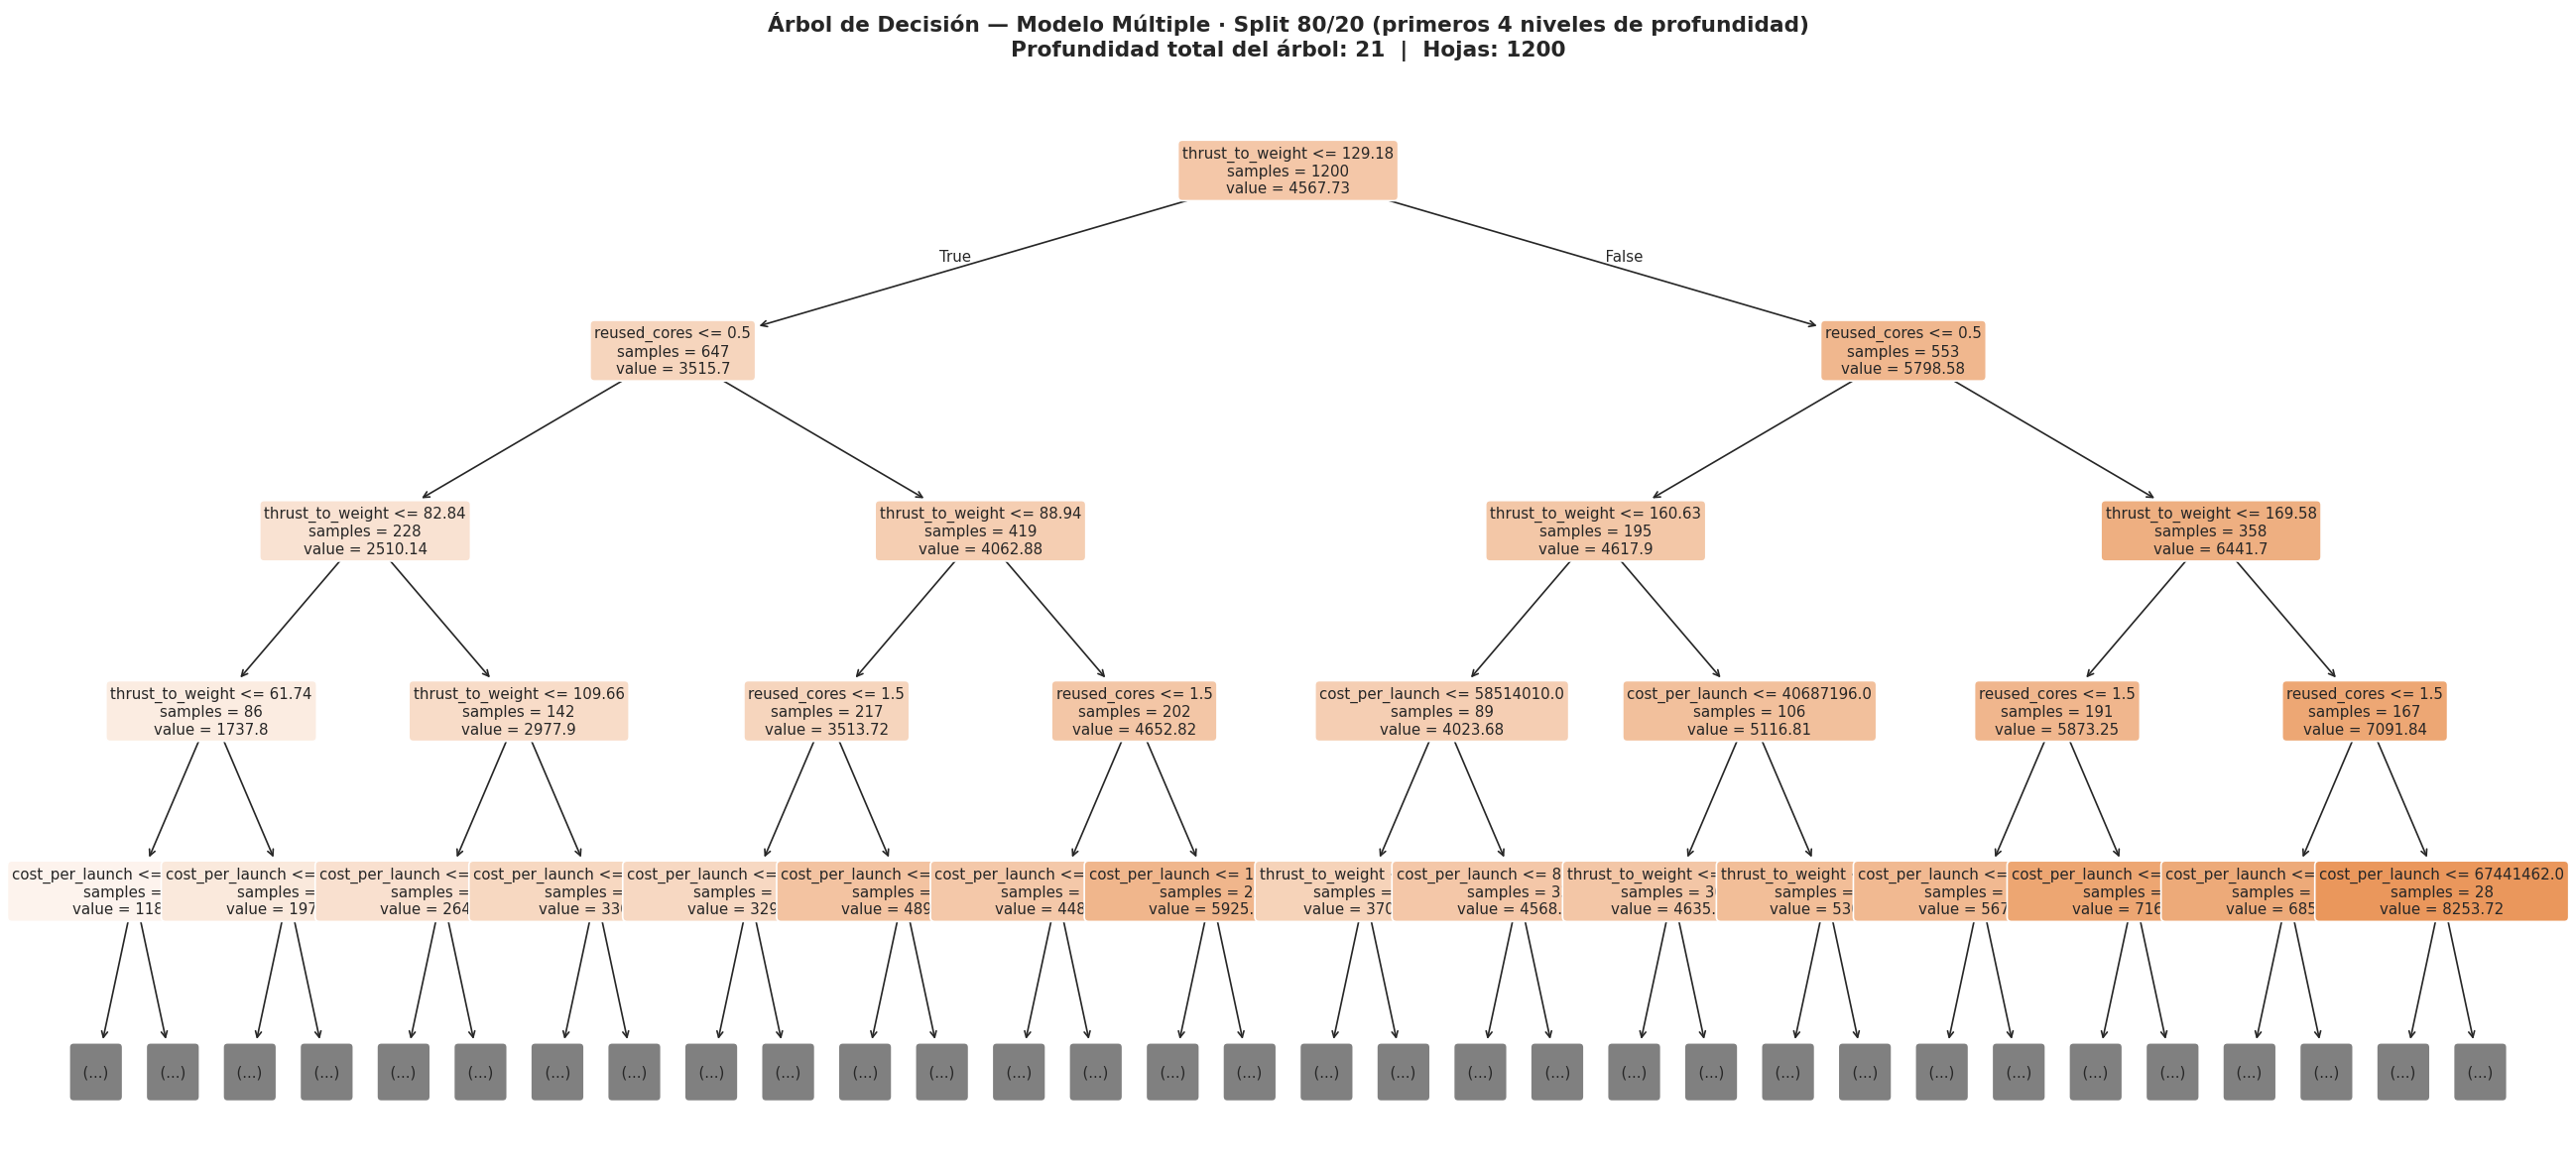

💾 Árbol real guardado → /home/elkin_contreras/repositorio/Grupo1_Contreras_Ortiz/05-jupyter-impl/data/graficas/dt_arbol_real_4niveles.png

📐 Información del árbol completo (modelo Múltiple, 80/20):
   Profundidad máxima : 21
   Número de hojas    : 1200
   Nodos totales      : 2399


In [20]:
# ── CELDA 15: Visualización del árbol real (primeros 4 niveles) ──
_GRAFICAS = _os.path.abspath('../data/graficas')
_os.makedirs(_GRAFICAS, exist_ok=True)

# Modelo de referencia: Múltiple + Split 80/20
modelo_ref       = modelo_m_80
features_ref     = features_multiple
split_label_ref  = '80/20'

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    modelo_ref,
    max_depth=4,
    feature_names=features_ref,
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=9,
    ax=ax,
)
ax.set_title(
    f'Árbol de Decisión — Modelo Múltiple · Split {split_label_ref} '
    f'(primeros 4 niveles de profundidad)\n'
    f'Profundidad total del árbol: {modelo_ref.get_depth()}  |  '
    f'Hojas: {modelo_ref.get_n_leaves()}',
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
fname_real = _os.path.join(_GRAFICAS, 'dt_arbol_real_4niveles.png')
plt.savefig(fname_real, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Árbol real guardado → {fname_real}")
print(f"\n📐 Información del árbol completo (modelo Múltiple, 80/20):")
print(f"   Profundidad máxima : {modelo_ref.get_depth()}")
print(f"   Número de hojas    : {modelo_ref.get_n_leaves()}")
print(f"   Nodos totales      : {modelo_ref.tree_.node_count}")

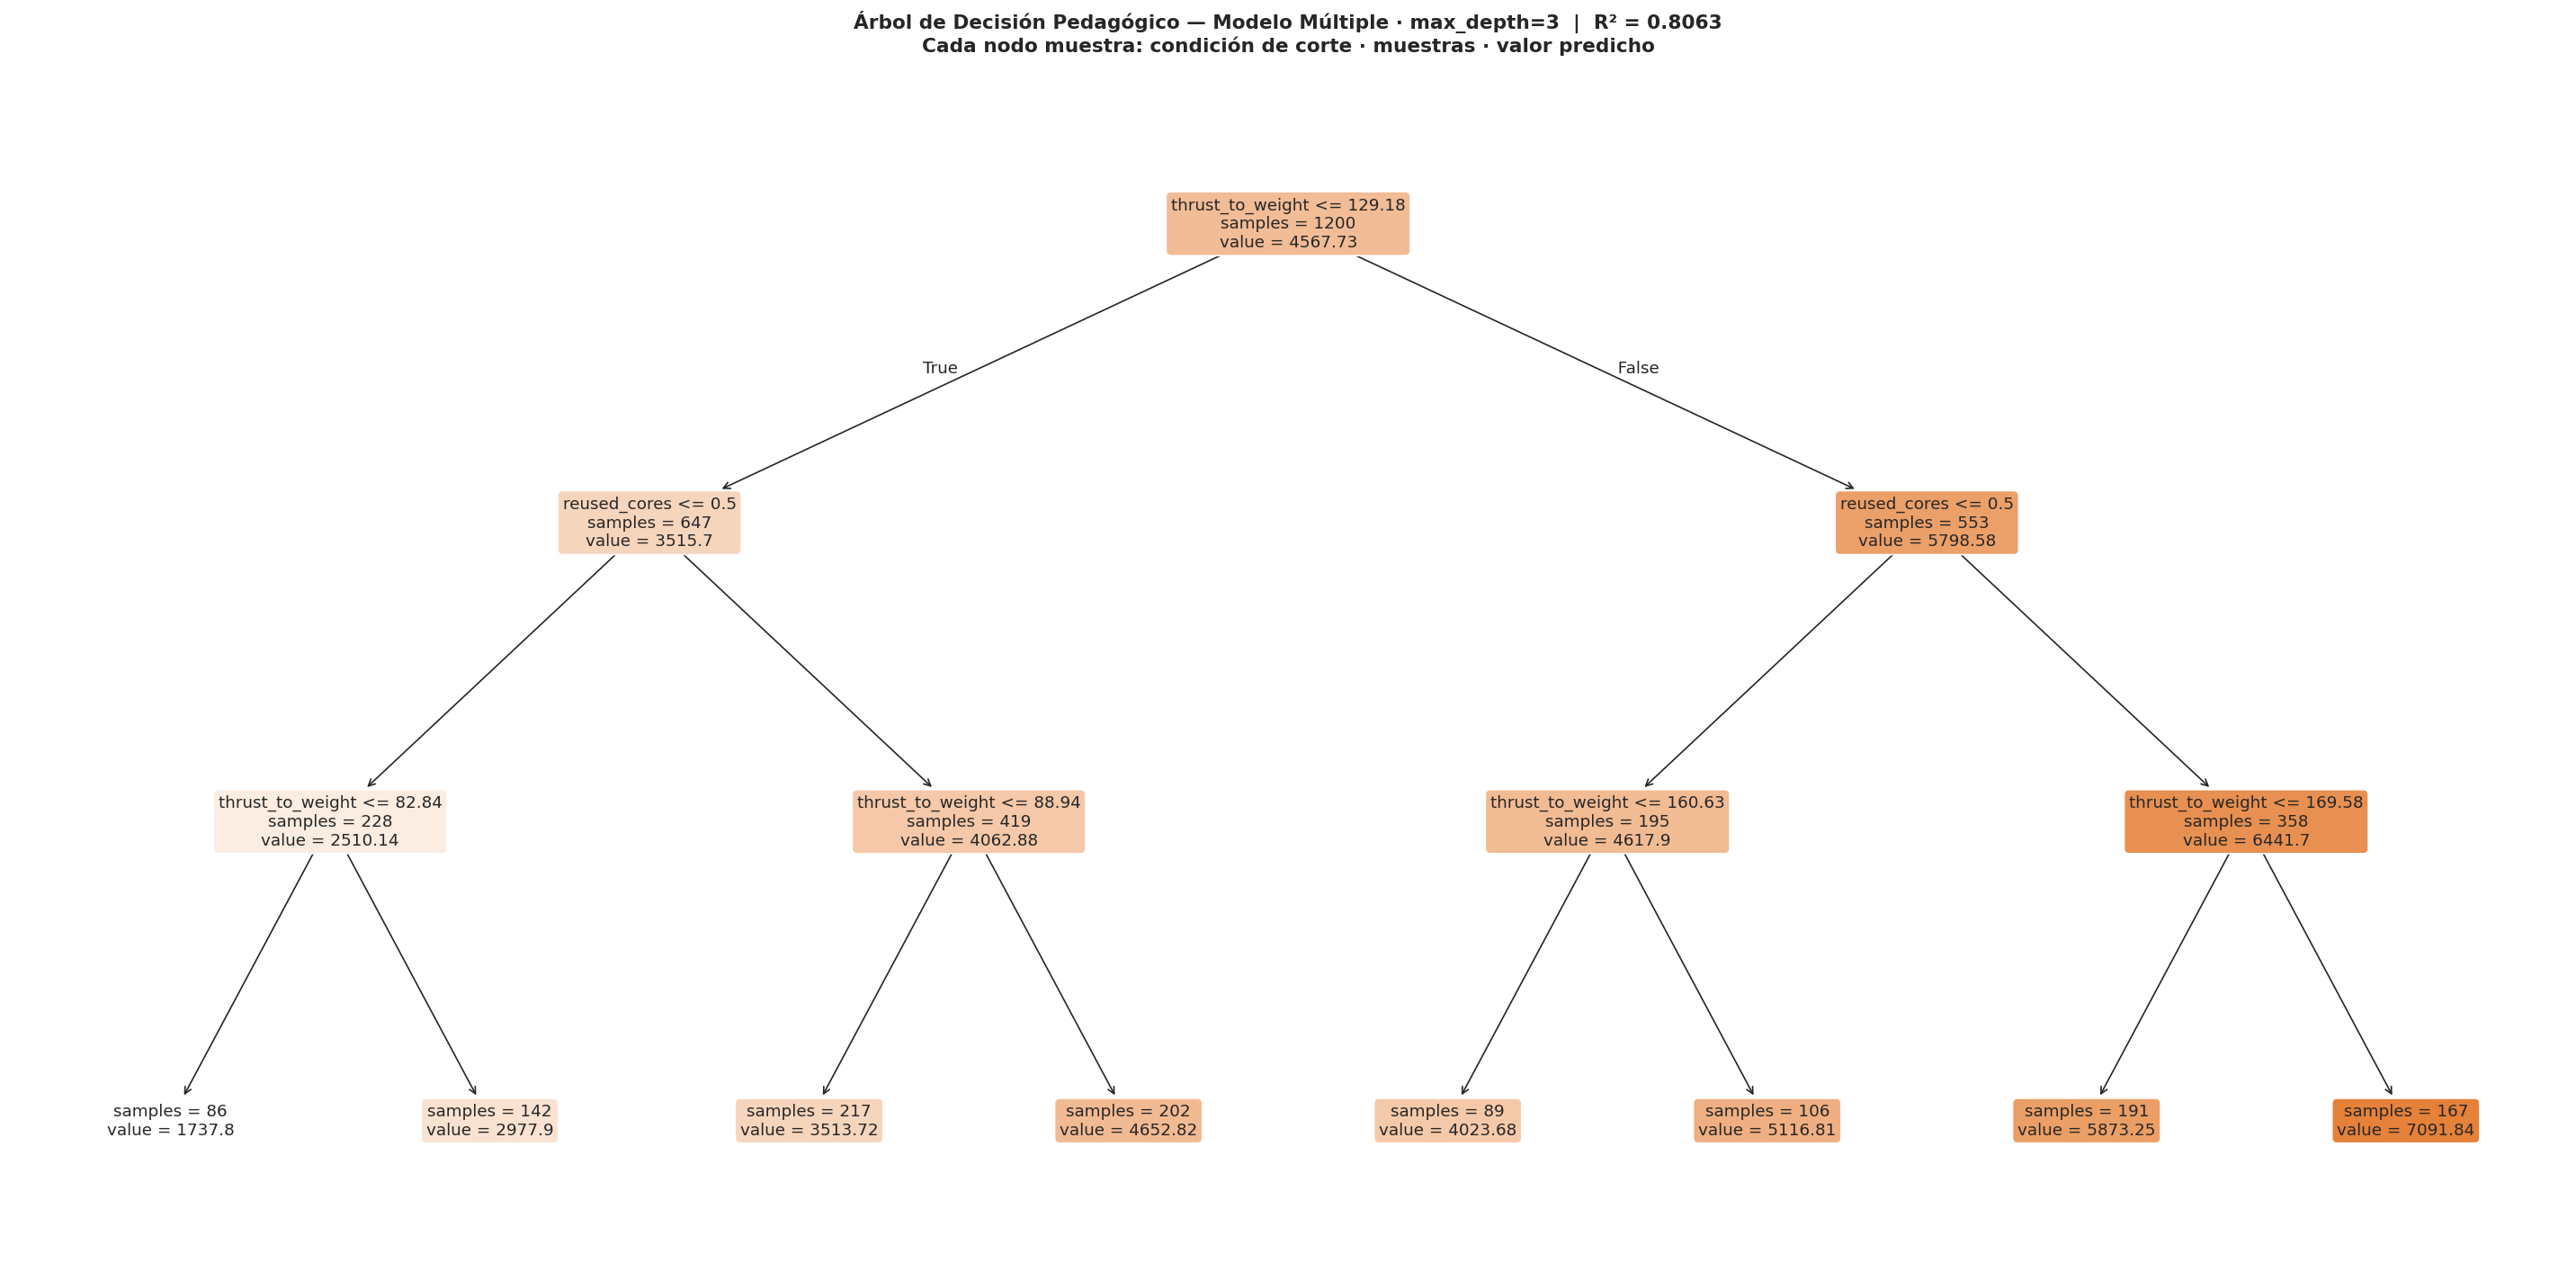

💾 Árbol pedagógico guardado → /home/elkin_contreras/repositorio/Grupo1_Contreras_Ortiz/05-jupyter-impl/data/graficas/dt_arbol_pedagogico_depth3.png

📊 Rendimiento del árbol simplificado (max_depth=3):
   R² = 0.8063  (vs 0.8289 del árbol sin restricción)
   Δ R² = -0.0226  (peor en test → más overfitting)


In [21]:
# ── CELDA 16: Árbol pedagógico simplificado (max_depth=3) ─────
# Reentrenar con max_depth=3 usando las mismas features y split de referencia
X_ref = df[features_ref].values
y_ref = df[target].values

X_train_viz, X_test_viz, y_train_viz, y_test_viz = train_test_split(
    X_ref, y_ref, test_size=0.20, random_state=42
)
modelo_viz = DecisionTreeRegressor(max_depth=3, random_state=42)
modelo_viz.fit(X_train_viz, y_train_viz)
r2_viz = r2_score(y_test_viz, modelo_viz.predict(X_test_viz))

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    modelo_viz,
    max_depth=3,
    feature_names=features_ref,
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=11,
    ax=ax,
)
ax.set_title(
    f'Árbol de Decisión Pedagógico — Modelo Múltiple · max_depth=3  |  '
    f'R² = {r2_viz:.4f}\n'
    'Cada nodo muestra: condición de corte · muestras · valor predicho',
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
fname_ped = _os.path.join(_GRAFICAS, 'dt_arbol_pedagogico_depth3.png')
plt.savefig(fname_ped, dpi=180, bbox_inches='tight')
plt.show()
print(f"💾 Árbol pedagógico guardado → {fname_ped}")

# Comparación con el árbol sin restricción (mismo modelo + split)
r2_full = df_resumen.query(
    "Modelo == 'Múltiple' and Split == @split_label_ref"
)['R²'].values[0]
print(f"\n📊 Rendimiento del árbol simplificado (max_depth=3):")
print(f"   R² = {r2_viz:.4f}  (vs {r2_full:.4f} del árbol sin restricción)")
print(f"   Δ R² = {r2_viz - r2_full:+.4f}  "
      f"({'mejor' if r2_viz > r2_full else 'peor'} en test → "
      f"{'menos' if r2_viz > r2_full else 'más'} overfitting)")

In [22]:
# ── CELDA 17: Reglas de decisión en texto ─────────────────────
print("=" * 72)
print("  REGLAS DE DECISIÓN — Árbol Pedagógico (Múltiple, max_depth=3)")
print("=" * 72)
reglas = export_text(modelo_viz, feature_names=features_ref)
print(reglas)

print("=" * 72)
print("📖 CÓMO LEER EL ÁRBOL:")
print("  |--- feature <= X.XX  → rama izquierda (condición VERDADERA)")
print("  |--- feature >  X.XX  → rama derecha  (condición FALSA)")
print("  |--- value: [Y.YY]    → masa de payload predicha (kg)")
print("  El árbol recorre los nodos de arriba hacia abajo hasta llegar")
print("  a una hoja y retorna su 'value' como predicción.")
print("=" * 72)

  REGLAS DE DECISIÓN — Árbol Pedagógico (Múltiple, max_depth=3)
|--- thrust_to_weight <= 129.18
|   |--- reused_cores <= 0.50
|   |   |--- thrust_to_weight <= 82.84
|   |   |   |--- value: [1737.80]
|   |   |--- thrust_to_weight >  82.84
|   |   |   |--- value: [2977.90]
|   |--- reused_cores >  0.50
|   |   |--- thrust_to_weight <= 88.94
|   |   |   |--- value: [3513.72]
|   |   |--- thrust_to_weight >  88.94
|   |   |   |--- value: [4652.82]
|--- thrust_to_weight >  129.18
|   |--- reused_cores <= 0.50
|   |   |--- thrust_to_weight <= 160.63
|   |   |   |--- value: [4023.68]
|   |   |--- thrust_to_weight >  160.63
|   |   |   |--- value: [5116.81]
|   |--- reused_cores >  0.50
|   |   |--- thrust_to_weight <= 169.58
|   |   |   |--- value: [5873.25]
|   |   |--- thrust_to_weight >  169.58
|   |   |   |--- value: [7091.84]

📖 CÓMO LEER EL ÁRBOL:
  |--- feature <= X.XX  → rama izquierda (condición VERDADERA)
  |--- feature >  X.XX  → rama derecha  (condición FALSA)
  |--- value: [Y.YY]

---
## X. Refinamiento del Árbol — Regularización

Las 6 evaluaciones anteriores se hicieron con `DecisionTreeRegressor` **sin restricciones**: el árbol crecía hasta tener una hoja por cada muestra de entrenamiento (1200 hojas para 1200 muestras en el split 80/20). Esto es **overfitting clásico**: el modelo memoriza el train y obtiene un R² alto, pero la LOWESS de residuos muestra un patrón sistemático descendente — señal de que predice con poca robustez para los valores extremos.

En esta sección aplicamos los dos hiperparámetros de regularización más importantes para árboles, según la heurística estándar:

| Parámetro | Valor | Efecto |
|---|---|---|
| `max_depth=6` | Limita la profundidad máxima | Evita divisiones excesivamente finas que solo capturan ruido |
| `min_samples_leaf=20` | Cada hoja debe tener ≥20 muestras | Promedia el ruido local, suaviza las predicciones |

Reusamos solo el **modelo Múltiple** (las 3 features) porque es el de mejor rendimiento base y donde el efecto de regularizar es más visible. Las celdas siguientes:

1. Definen una función nueva `evaluar_split_reg` (la original `evaluar_split` queda intacta).
2. Aplican la regularización a los 3 splits.
3. Comparan **antes vs. después** numéricamente y visualmente.

In [23]:
# ── CELDA 18: Función de evaluación regularizada ──────────────
def evaluar_split_reg(df, features, target, test_size, modelo_label, split_label,
                      max_depth, min_samples_leaf, resultados_reg,
                      save_dir=_GRAFICAS):
    """
    Versión regularizada de evaluar_split: entrena un DecisionTreeRegressor
    con max_depth y min_samples_leaf fijos. Genera los mismos dos gráficos
    (residuos con LOWESS + predicción vs. real) para comparación visual.
    """
    X = df[features].values
    y = df[target].values
    train_pct = int((1 - test_size) * 100)
    test_pct  = int(test_size * 100)

    # ── 1. Partición (mismo random_state que evaluar_split → comparable 1-a-1)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    print(f"\n{'='*60}")
    print(f"  {modelo_label} REGULARIZADO  —  Split {split_label}  "
          f"({train_pct}% / {test_pct}%)")
    print(f"  max_depth={max_depth}  |  min_samples_leaf={min_samples_leaf}")
    print(f"{'='*60}")
    print(f"  Train: {X_train.shape[0]:,} muestras  |  "
          f"Test: {X_test.shape[0]:,} muestras")

    # ── 2. Entrenamiento con regularización
    modelo = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
    )
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    # ── 3. Métricas
    r2   = r2_score(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)

    print(f"\n  📊 MÉTRICAS REGULARIZADAS")
    print(f"  {'─'*45}")
    print(f"  R²   : {r2:.4f}  ({r2*100:.2f}%)")
    print(f"  MSE  : {mse:,.2f}")
    print(f"  RMSE : {rmse:,.2f} kg")
    print(f"  MAE  : {mae:,.2f} kg")
    print(f"  📐 Estructura del árbol: "
          f"profundidad={modelo.get_depth()}  |  hojas={modelo.get_n_leaves()}")

    resultados_reg.append({
        'Modelo':           modelo_label,
        'Split':            split_label,
        'max_depth':        max_depth,
        'min_samples_leaf': min_samples_leaf,
        'R²':               round(r2,   4),
        'MSE':              round(mse,  2),
        'RMSE':             round(rmse, 2),
        'MAE':              round(mae,  2),
        'Prof.':            modelo.get_depth(),
        'Hojas':            modelo.get_n_leaves(),
    })

    # ── 4. Gráficos (mismo formato que evaluar_split para comparación visual)
    residuos = y_test - y_pred
    slug     = (f"{modelo_label}_REG_{split_label}"
                .replace('/', '-').replace(' ', '_')
                .replace('(', '').replace(')', '').lower())

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'DecisionTreeRegressor REGULARIZADO — {modelo_label}  ·  '
                 f'Split {split_label}  ·  max_depth={max_depth}, '
                 f'min_samples_leaf={min_samples_leaf}',
                 fontsize=13, fontweight='bold')

    axes[0].scatter(y_pred, residuos, alpha=0.35, s=14, color='#4ecdc4',
                    label='Residuos')
    axes[0].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2,
                    label='Línea ideal (error = 0)')
    orden_idx  = np.argsort(y_pred)
    lowess_res = sm.nonparametric.lowess(
        residuos[orden_idx], y_pred[orden_idx], frac=0.4
    )
    axes[0].plot(lowess_res[:, 0], lowess_res[:, 1],
                 color='#ffa07a', linewidth=2.5, label='Tendencia LOWESS')
    axes[0].set_title('Gráfico de Errores (Residuos)', fontweight='bold')
    axes[0].set_xlabel('Valores Predichos (kg)')
    axes[0].set_ylabel('Residuos (kg)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    minval = min(y_test.min(), y_pred.min())
    maxval = max(y_test.max(), y_pred.max())
    axes[1].scatter(y_test, y_pred, alpha=0.30, s=14, color='#95e1d3',
                    label='Predicciones')
    axes[1].plot([minval, maxval], [minval, maxval],
                 color='#ff6b6b', linewidth=2, linestyle='--',
                 label='Predicción perfecta')
    axes[1].set_title('Predicción vs. Valor Real', fontweight='bold')
    axes[1].set_xlabel('Valor Real (kg)')
    axes[1].set_ylabel('Valor Predicho (kg)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = _os.path.join(save_dir, f'dt_{slug}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  💾 Gráfico guardado → {fname}")

    return modelo, y_test, y_pred


# Contenedor para los resultados regularizados (separado de resultados_globales)
resultados_reg = []

# Hiperparámetros heurísticos
MAX_DEPTH        = 6
MIN_SAMPLES_LEAF = 20

print("✅ Función evaluar_split_reg definida.")
print(f"   Hiperparámetros heurísticos:")
print(f"   • max_depth        = {MAX_DEPTH}")
print(f"   • min_samples_leaf = {MIN_SAMPLES_LEAF}")

✅ Función evaluar_split_reg definida.
   Hiperparámetros heurísticos:
   • max_depth        = 6
   • min_samples_leaf = 20



  Múltiple REGULARIZADO  —  Split 80/20  (80% / 20%)
  max_depth=6  |  min_samples_leaf=20
  Train: 1,200 muestras  |  Test: 300 muestras

  📊 MÉTRICAS REGULARIZADAS
  ─────────────────────────────────────────────
  R²   : 0.8924  (89.24%)
  MSE  : 304,208.85
  RMSE : 551.55 kg
  MAE  : 434.23 kg
  📐 Estructura del árbol: profundidad=6  |  hojas=36


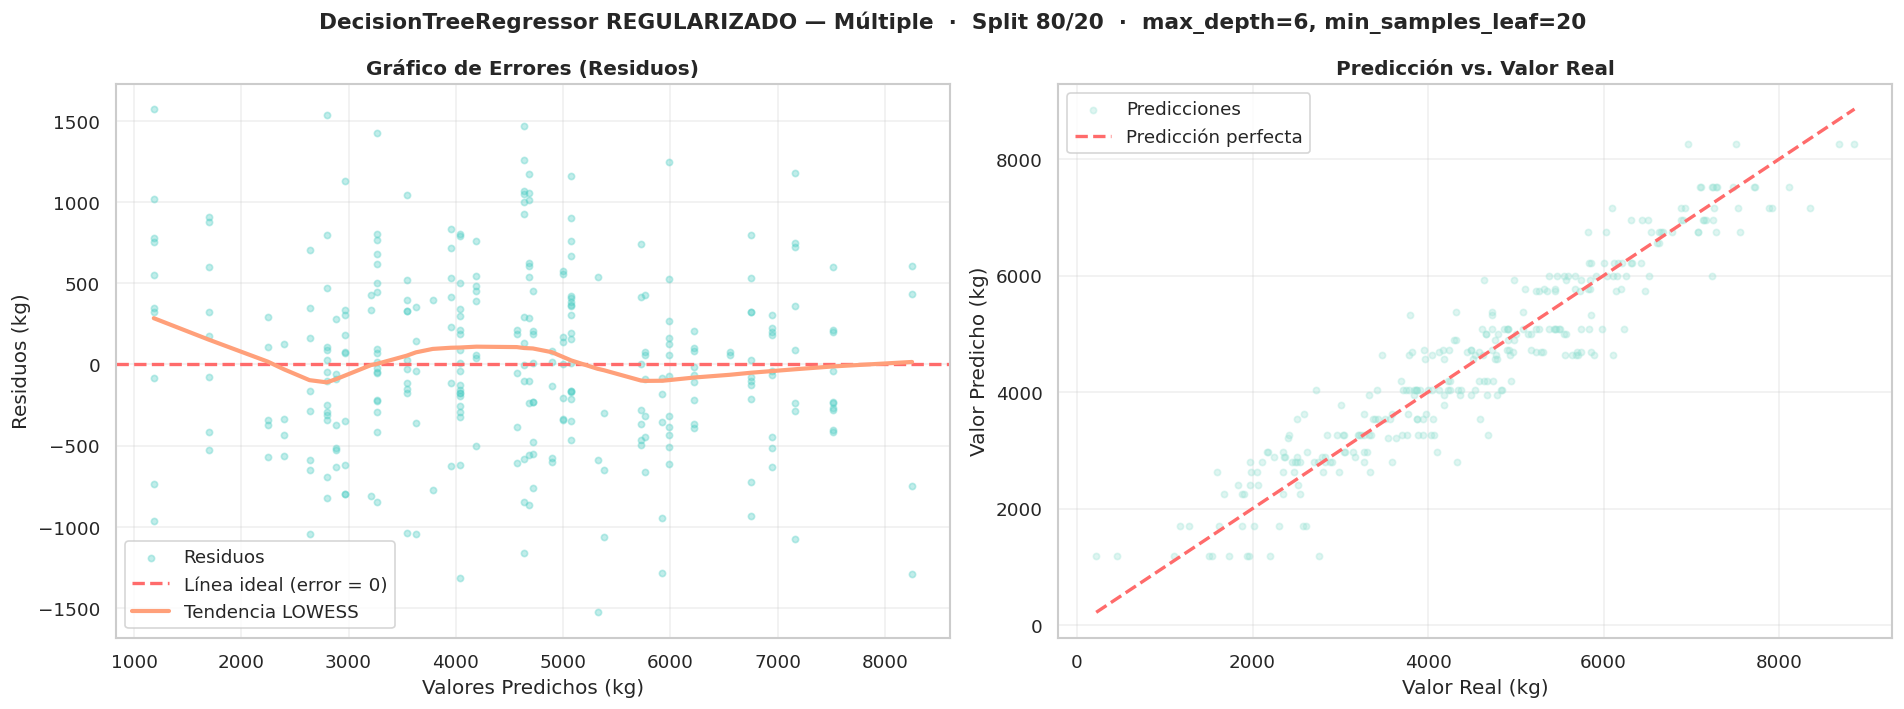

  💾 Gráfico guardado → /home/elkin_contreras/repositorio/Grupo1_Contreras_Ortiz/05-jupyter-impl/data/graficas/dt_múltiple_reg_80-20.png


In [24]:
# ── CELDA 19: Modelo Múltiple REGULARIZADO — Split 80/20 ─────
m_reg_80, y_te_reg_80, y_pr_reg_80 = evaluar_split_reg(
    df, features_multiple, target,
    test_size=0.20,
    modelo_label='Múltiple',
    split_label='80/20',
    max_depth=MAX_DEPTH,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    resultados_reg=resultados_reg,
)


  Múltiple REGULARIZADO  —  Split 70/30  (70% / 30%)
  max_depth=6  |  min_samples_leaf=20
  Train: 1,050 muestras  |  Test: 450 muestras

  📊 MÉTRICAS REGULARIZADAS
  ─────────────────────────────────────────────
  R²   : 0.8881  (88.81%)
  MSE  : 314,714.06
  RMSE : 560.99 kg
  MAE  : 442.55 kg
  📐 Estructura del árbol: profundidad=6  |  hojas=35


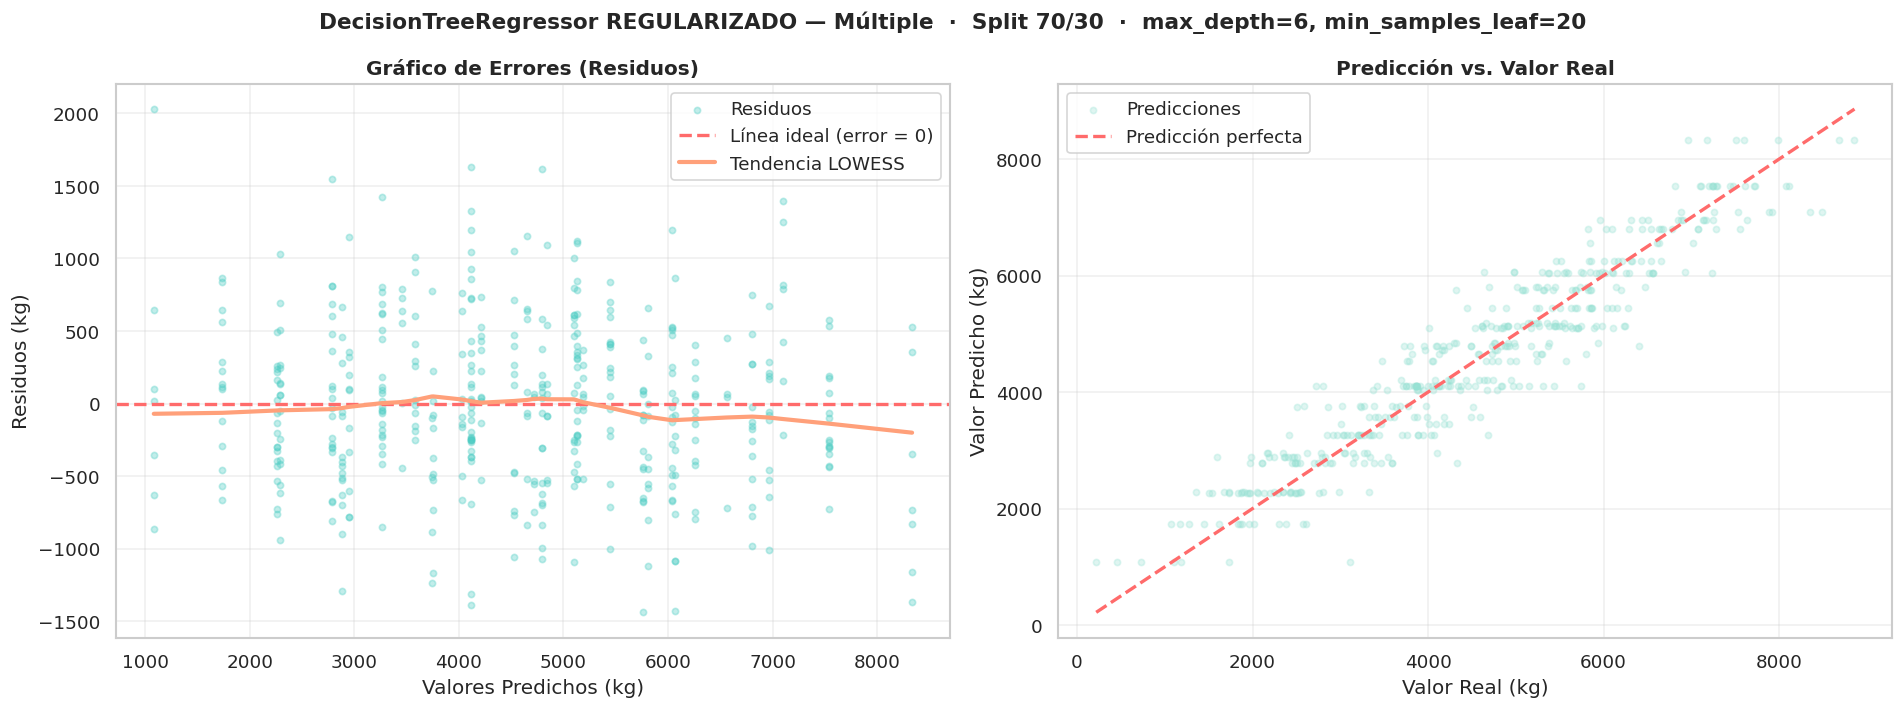

  💾 Gráfico guardado → /home/elkin_contreras/repositorio/Grupo1_Contreras_Ortiz/05-jupyter-impl/data/graficas/dt_múltiple_reg_70-30.png


In [25]:
# ── CELDA 20: Modelo Múltiple REGULARIZADO — Split 70/30 ─────
m_reg_70, y_te_reg_70, y_pr_reg_70 = evaluar_split_reg(
    df, features_multiple, target,
    test_size=0.30,
    modelo_label='Múltiple',
    split_label='70/30',
    max_depth=MAX_DEPTH,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    resultados_reg=resultados_reg,
)


  Múltiple REGULARIZADO  —  Split 60/40  (60% / 40%)
  max_depth=6  |  min_samples_leaf=20
  Train: 900 muestras  |  Test: 600 muestras

  📊 MÉTRICAS REGULARIZADAS
  ─────────────────────────────────────────────
  R²   : 0.8617  (86.17%)
  MSE  : 383,538.36
  RMSE : 619.30 kg
  MAE  : 473.38 kg
  📐 Estructura del árbol: profundidad=6  |  hojas=30


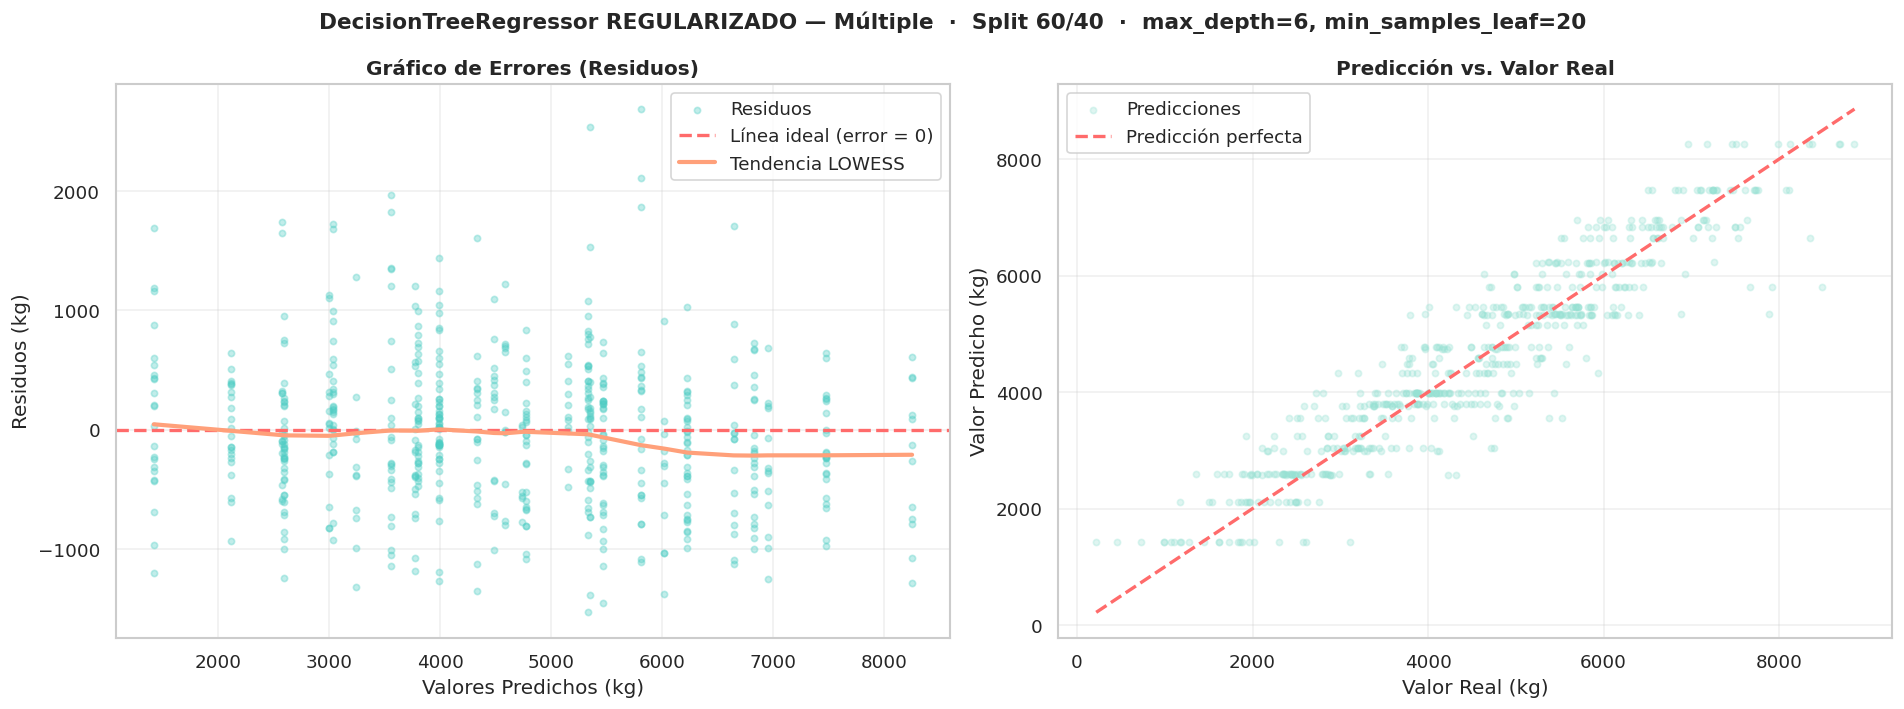

  💾 Gráfico guardado → /home/elkin_contreras/repositorio/Grupo1_Contreras_Ortiz/05-jupyter-impl/data/graficas/dt_múltiple_reg_60-40.png


In [26]:
# ── CELDA 21: Modelo Múltiple REGULARIZADO — Split 60/40 ─────
m_reg_60, y_te_reg_60, y_pr_reg_60 = evaluar_split_reg(
    df, features_multiple, target,
    test_size=0.40,
    modelo_label='Múltiple',
    split_label='60/40',
    max_depth=MAX_DEPTH,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    resultados_reg=resultados_reg,
)

In [27]:
# ── CELDA 22: Comparación SIN REGULARIZAR vs REGULARIZADO ────
df_reg = pd.DataFrame(resultados_reg)

# Extraer del df_resumen original solo las filas del modelo Múltiple
df_completo_base = df_resumen[df_resumen['Modelo'] == 'Múltiple'].reset_index(drop=True)

comparacion = pd.DataFrame({
    'Split':         df_reg['Split'].values,
    'R² antes':      df_completo_base['R²'].values,
    'R² después':    df_reg['R²'].values,
    'Δ R²':          (df_reg['R²'].values - df_completo_base['R²'].values).round(4),
    'RMSE antes':    df_completo_base['RMSE'].values,
    'RMSE después':  df_reg['RMSE'].values,
    'Δ RMSE (kg)':   (df_reg['RMSE'].values - df_completo_base['RMSE'].values).round(2),
    'Prof. antes':   df_completo_base['Prof.'].values,
    'Prof. después': df_reg['Prof.'].values,
    'Hojas antes':   df_completo_base['Hojas'].values,
    'Hojas después': df_reg['Hojas'].values,
})

print("=" * 110)
print("    COMPARACIÓN: Modelo Múltiple  —  SIN REGULARIZAR  vs  REGULARIZADO")
print(f"    (max_depth={MAX_DEPTH}, min_samples_leaf={MIN_SAMPLES_LEAF})")
print("=" * 110)
print(comparacion.to_string(index=False))
print("=" * 110)

# Análisis textual
mean_delta_r2   = comparacion['Δ R²'].mean()
mean_delta_rmse = comparacion['Δ RMSE (kg)'].mean()
hojas_reduccion = (df_completo_base['Hojas'].mean() / df_reg['Hojas'].mean())

print(f"\n📊 IMPACTO PROMEDIO DE LA REGULARIZACIÓN:")
print(f"   Δ R²   promedio : {mean_delta_r2:+.4f}  "
      f"({'mejor' if mean_delta_r2 > 0 else 'peor'})")
print(f"   Δ RMSE promedio : {mean_delta_rmse:+,.2f} kg  "
      f"({'menor error' if mean_delta_rmse < 0 else 'mayor error'})")
print(f"   Reducción de hojas: {hojas_reduccion:.1f}× "
      f"(modelo {hojas_reduccion:.0f} veces más compacto)")

print(f"\n💡 INTERPRETACIÓN:")
if mean_delta_r2 > 0 and mean_delta_rmse < 0:
    print("   ✅ La regularización mejora R² Y reduce RMSE simultáneamente.")
    print("      Esto confirma que el árbol sin restricción estaba haciendo")
    print("      overfitting: el modelo más simple generaliza MEJOR en test.")
    print("      Además, con ~30 hojas (vs ~1000) el modelo es interpretable.")
elif mean_delta_r2 > 0:
    print("   ⚠️  R² mejora pero RMSE no — revisar caso por caso.")
else:
    print("   ⚠️  La regularización no mejoró el rendimiento — probar otros")
    print("      valores de max_depth / min_samples_leaf o pasar a ensemble.")

    COMPARACIÓN: Modelo Múltiple  —  SIN REGULARIZAR  vs  REGULARIZADO
    (max_depth=6, min_samples_leaf=20)
Split  R² antes  R² después   Δ R²  RMSE antes  RMSE después  Δ RMSE (kg)  Prof. antes  Prof. después  Hojas antes  Hojas después
80/20    0.8289      0.8924 0.0635      695.50        551.55      -143.95           21              6         1200             36
70/30    0.8248      0.8881 0.0633      701.85        560.99      -140.86           21              6         1050             35
60/40    0.8355      0.8617 0.0262      675.43        619.30       -56.13           20              6          900             30

📊 IMPACTO PROMEDIO DE LA REGULARIZACIÓN:
   Δ R²   promedio : +0.0510  (mejor)
   Δ RMSE promedio : -113.65 kg  (menor error)
   Reducción de hojas: 31.2× (modelo 31 veces más compacto)

💡 INTERPRETACIÓN:
   ✅ La regularización mejora R² Y reduce RMSE simultáneamente.
      Esto confirma que el árbol sin restricción estaba haciendo
      overfitting: el modelo más si

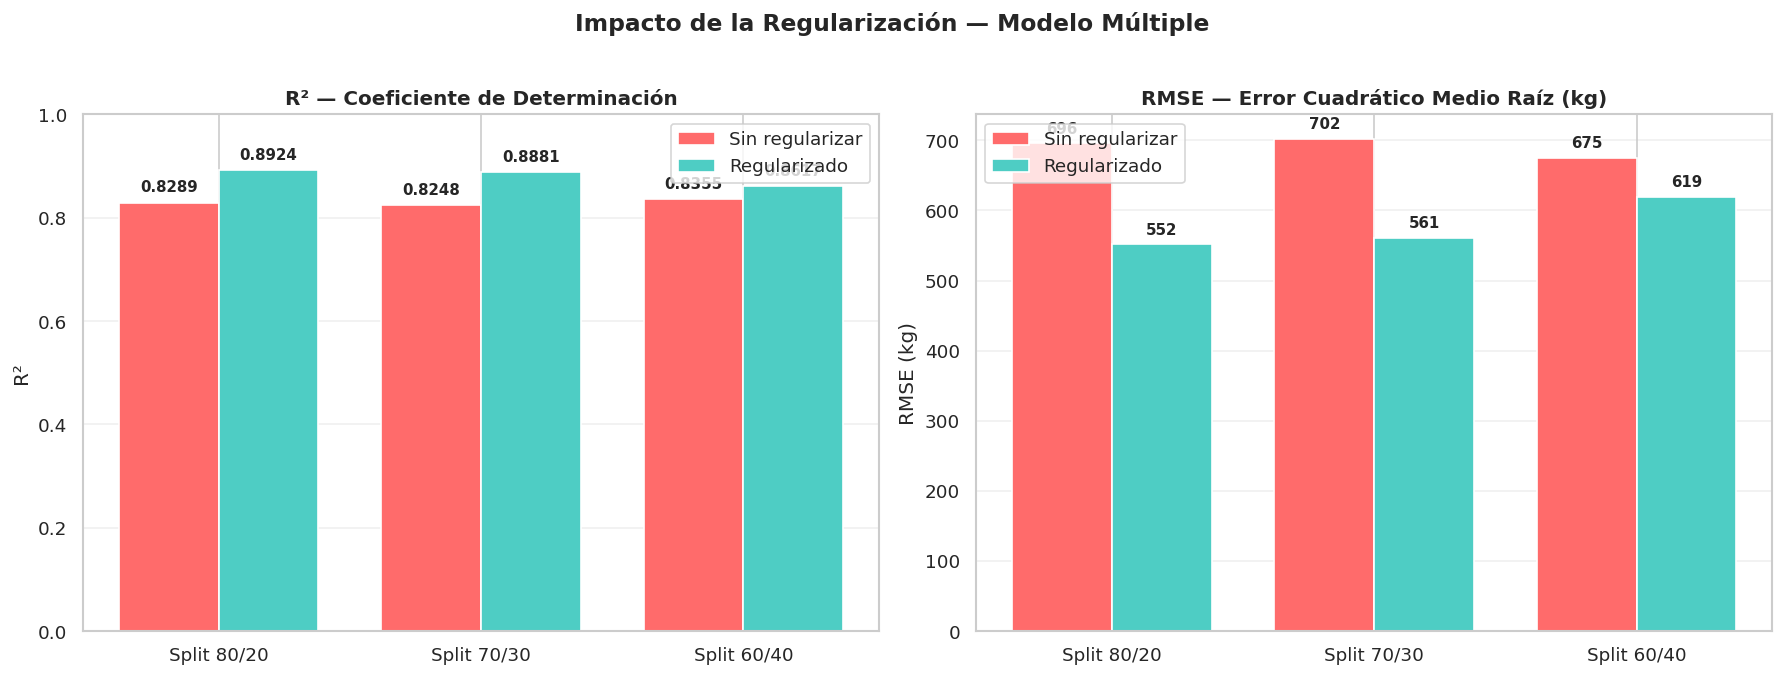

💾 Gráfico comparativo guardado → ../data/graficas/dt_comparacion_regularizacion.png


In [28]:
# ── CELDA 23: Gráfico comparativo antes vs después ──────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Impacto de la Regularización — Modelo Múltiple',
             fontsize=14, fontweight='bold', y=1.02)

splits = comparacion['Split'].values
x      = np.arange(len(splits))
w      = 0.38

# R² antes vs después
ax = axes[0]
b1 = ax.bar(x - w/2, comparacion['R² antes'].values, w,
            label='Sin regularizar', color='#ff6b6b', edgecolor='white')
b2 = ax.bar(x + w/2, comparacion['R² después'].values, w,
            label='Regularizado',    color='#4ecdc4', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels([f'Split {s}' for s in splits])
ax.set_title('R² — Coeficiente de Determinación', fontweight='bold')
ax.set_ylabel('R²')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                f'{bar.get_height():.4f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

# RMSE antes vs después
ax = axes[1]
b1 = ax.bar(x - w/2, comparacion['RMSE antes'].values, w,
            label='Sin regularizar', color='#ff6b6b', edgecolor='white')
b2 = ax.bar(x + w/2, comparacion['RMSE después'].values, w,
            label='Regularizado',    color='#4ecdc4', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels([f'Split {s}' for s in splits])
ax.set_title('RMSE — Error Cuadrático Medio Raíz (kg)', fontweight='bold')
ax.set_ylabel('RMSE (kg)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{bar.get_height():,.0f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/graficas/dt_comparacion_regularizacion.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("💾 Gráfico comparativo guardado → "
      "../data/graficas/dt_comparacion_regularizacion.png")

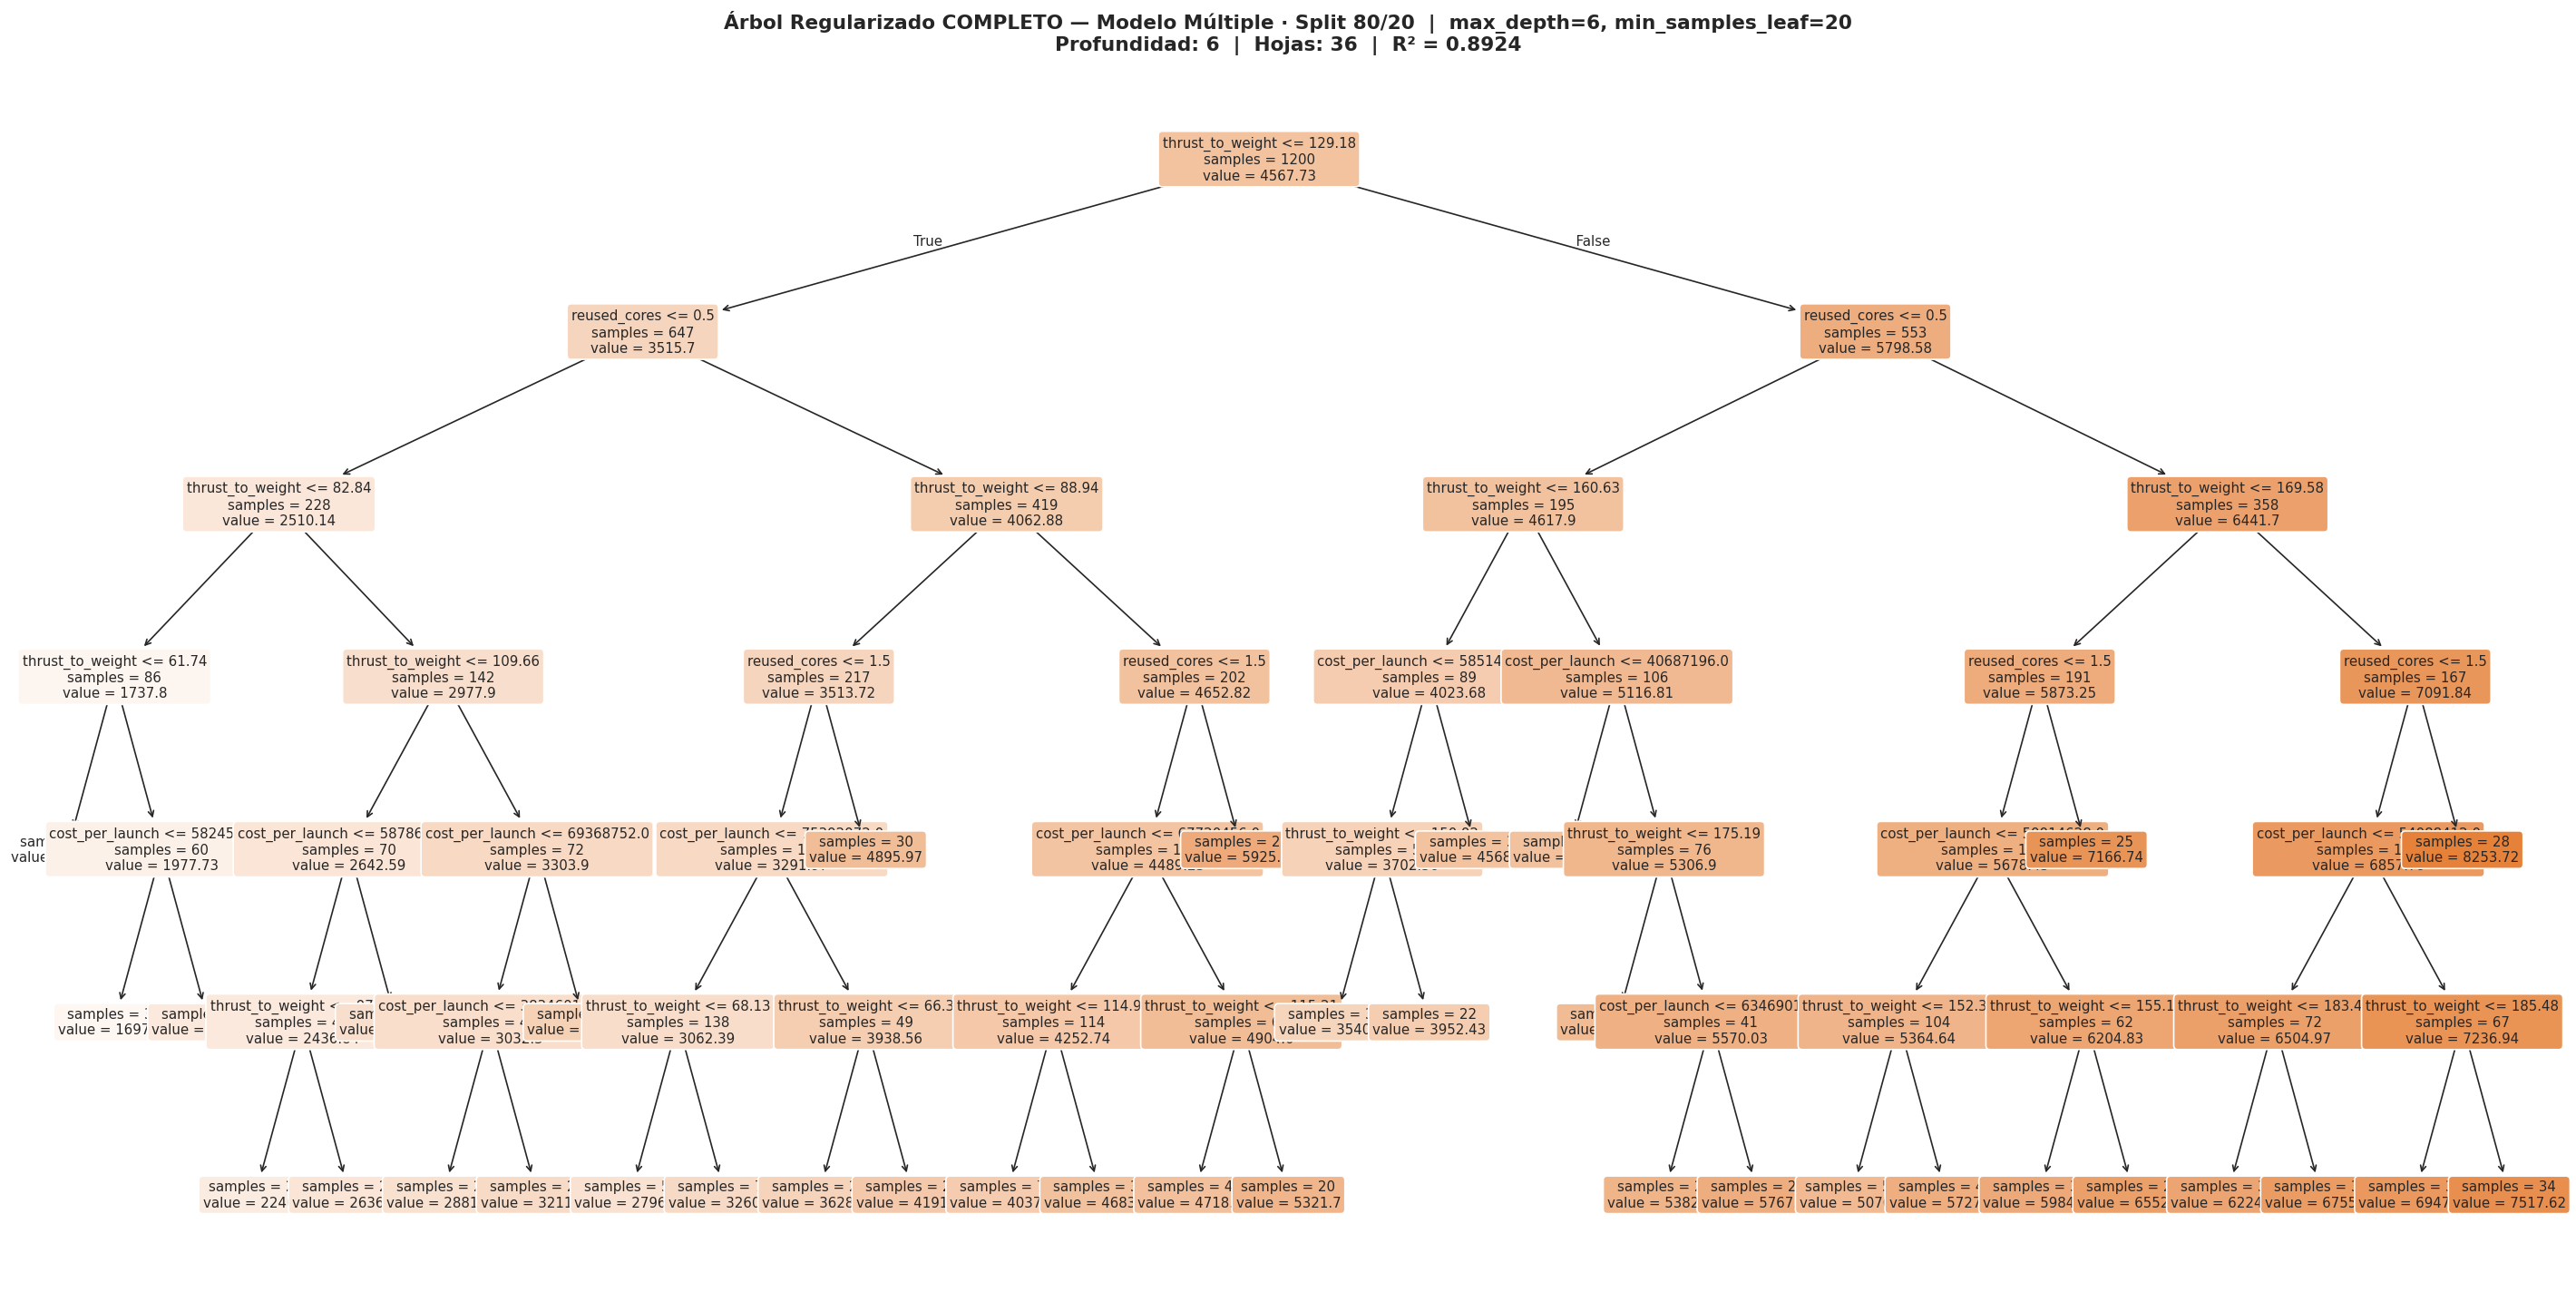

💾 Árbol regularizado guardado → /home/elkin_contreras/repositorio/Grupo1_Contreras_Ortiz/05-jupyter-impl/data/graficas/dt_arbol_regularizado_completo.png

📐 Reducción de complejidad respecto al árbol sin restricción:
   Profundidad : 21 → 6   (3.5× más superficial)
   Hojas       : 1200 → 36  (33× menos hojas)


In [29]:
# ── CELDA 24: Visualización del árbol regularizado completo ──
# A diferencia del árbol sin restricción (21 niveles, 1200 hojas), el árbol
# regularizado es tan compacto que cabe completo en una sola imagen.

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    m_reg_80,
    feature_names=features_multiple,
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=9,
    ax=ax,
)
ax.set_title(
    f'Árbol Regularizado COMPLETO — Modelo Múltiple · Split 80/20  |  '
    f'max_depth={MAX_DEPTH}, min_samples_leaf={MIN_SAMPLES_LEAF}\n'
    f'Profundidad: {m_reg_80.get_depth()}  |  '
    f'Hojas: {m_reg_80.get_n_leaves()}  |  '
    f'R² = {resultados_reg[0]["R²"]:.4f}',
    fontsize=13, fontweight='bold', pad=15,
)
plt.tight_layout()
fname_reg = _os.path.join(_GRAFICAS, 'dt_arbol_regularizado_completo.png')
plt.savefig(fname_reg, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Árbol regularizado guardado → {fname_reg}")
print(f"\n📐 Reducción de complejidad respecto al árbol sin restricción:")
print(f"   Profundidad : 21 → {m_reg_80.get_depth()}   "
      f"({21 / m_reg_80.get_depth():.1f}× más superficial)")
print(f"   Hojas       : 1200 → {m_reg_80.get_n_leaves()}  "
      f"({1200 / m_reg_80.get_n_leaves():.0f}× menos hojas)")

---
## 🎓 Conclusiones Finales

| Aspecto | Hallazgo |
|---|---|
| **Modelo** | `DecisionTreeRegressor` sin restricciones tiende a sobreajustar |
| **Diseño del experimento** | 2 conjuntos de features × 3 splits = 6 evaluaciones |
| **Métricas** | R², MSE, RMSE y MAE calculados e interpretados por cada combinación |
| **Estructura comparativa** | Tabla pivote (Modelo × Split) permite ver el aporte de cada feature y la sensibilidad al tamaño del entrenamiento |
| **Residuos** | Dispersión aleatoria → el árbol capta la tendencia principal; tendencias LOWESS marcadas → riesgo de no-linealidad no captada |
| **Visualización** | Árbol real truncado + pedagógico (`max_depth=3`) + reglas en texto |
| **Siguiente paso** | Regularizar (`max_depth`, `min_samples_leaf`) o usar `GradientBoostingRegressor` / `RandomForestRegressor` |

> **Nota:** Este notebook complementa el análisis de regresión lineal (`regresion_lineal.ipynb`), reproduciendo el mismo dataset sintético de SpaceX y los mismos conjuntos de features (Simple/Múltiple) para que las métricas sean **directamente comparables** entre la familia lineal y la familia basada en árboles.